In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings("ignore")

In [2]:

file_path = "/content/cell_tower.csv"
df = pd.read_csv(file_path)

df['Latitude'] = df['Latitude'].astype(str).str.replace('"','').str.strip()
df['Longitude'] = df['Longitude'].astype(str).str.replace('"','').str.strip()

df = df[(df["Latitude"] != "") & (df["Longitude"] != "")]

df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

df = df.dropna(subset=['Latitude','Longitude']).reset_index(drop=True)

df = df[(df["Latitude"].between(-90, 90)) & (df["Longitude"].between(-180, 180))]
df.head()

,No.,Longitude,Latitude,Serving RSRP_4G
0,1,3.502389,6.437201,-62.5
1,2,3.502389,6.437201,-65.69
2,3,3.502389,6.437201,-65.38
3,4,3.502389,6.437201,-61.81
4,5,3.502389,6.437201,-65.06


In [3]:

lat = df['Latitude'].values
lon = df['Longitude'].values

dlat = np.diff(lat) * 111  # 1° latitude ≈ 111 km
mean_lat_rad = np.radians((lat[:-1] + lat[1:]) / 2)  # per-segment mean latitude
     # scaled longitude differences
dlon = np.diff(lon) * 111 * np.cos(mean_lat_rad)
step_distances = np.sqrt(dlat**2 + dlon**2)

total_distance_km = np.sum(step_distances)
print(f"Total Euclidean distance: {total_distance_km:.2f} km")


Total Euclidean distance: 274.73 km


In [4]:
import folium
m = folium.Map(location=[df['Latitude'].iloc[0], df['Longitude'].iloc[0]], zoom_start=15)
coords = list(zip(df['Latitude'], df['Longitude']))
folium.PolyLine(coords, color='blue', weight=4, opacity=0.7).add_to(m)

folium.Marker(coords[0], popup='Start', icon=folium.Icon(color='green')).add_to(m)
folium.Marker(coords[-1], popup='End', icon=folium.Icon(color='red')).add_to(m)

# Show map
m


In [5]:
import pandas as pd
import numpy as np
import folium

# 1️⃣ Load and clean data
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
df = df.dropna(subset=['Latitude', 'Longitude'])

# 2️⃣ Define grid dimensions
lat_min, lat_max = df['Latitude'].min(), df['Latitude'].max()
lon_min, lon_max = df['Longitude'].min(), df['Longitude'].max()

# Create 26×11 grid edges
lon_bins = np.linspace(lon_min, lon_max, 27)  # 27 edges = 26 columns
lat_bins = np.linspace(lat_min, lat_max, 12)  # 12 edges = 11 rows

# 3️⃣ Create the base map centered on the first coordinate
m = folium.Map(location=[df['Latitude'].iloc[0], df['Longitude'].iloc[0]], zoom_start=15)

# Add route (blue line)
coords = list(zip(df['Latitude'], df['Longitude']))
folium.PolyLine(coords, color='blue', weight=4, opacity=0.7).add_to(m)

# Add start and end markers
folium.Marker(coords[0], popup='Start', icon=folium.Icon(color='green')).add_to(m)
folium.Marker(coords[-1], popup='End', icon=folium.Icon(color='red')).add_to(m)

# 4️⃣ Add grid overlay (gray lines)
for lat in lat_bins:
    folium.PolyLine([(lat, lon_min), (lat, lon_max)], color='red', weight=1, opacity=0.5).add_to(m)

for lon in lon_bins:
    folium.PolyLine([(lat_min, lon), (lat_max, lon)], color='red', weight=1, opacity=0.5).add_to(m)

# 5️⃣ Show interactive map
m


In [6]:
import pandas as pd
import numpy as np
import folium

# Suppose your dataset looks like this:
# df = pd.read_csv("your_data.csv")
# Columns: Latitude, Longitude, RSRP


# ======================
# STEP 1 — Define grid size
# ======================
#0.004
grid_size = 0.005  # roughly 100–120 meters (you can make it smaller or larger)

# Get boundary of your data
min_lat, max_lat = df['Latitude'].min(), df['Latitude'].max()
min_lon, max_lon = df['Longitude'].min(), df['Longitude'].max()

# Create grid edges
lat_edges = np.arange(min_lat, max_lat + grid_size, grid_size)
lon_edges = np.arange(min_lon, max_lon + grid_size, grid_size)

# ======================
# STEP 2 — Assign each point to grid cell
# ======================
df['lat_bin'] = np.digitize(df['Latitude'], lat_edges)
df['lon_bin'] = np.digitize(df['Longitude'], lon_edges)

# ======================
# STEP 3 — Create Folium map
# ======================
m = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=14)

# --- Draw all grid rectangles on the map ---
for i in range(len(lat_edges)-1):
    for j in range(len(lon_edges)-1):
        # Define the corner points of each grid cell
        bounds = [
            [lat_edges[i], lon_edges[j]],        # bottom-left
            [lat_edges[i+1], lon_edges[j+1]]     # top-right
        ]
        # Draw the rectangle
        folium.Rectangle(
            bounds=bounds,
            color='gray',
            weight=1,
            fill=True,
            fill_opacity=0.05
        ).add_to(m)

# ======================
# STEP 4 — Add your UAV flight path
# ======================
coords = list(zip(df['Latitude'], df['Longitude']))

# Add the path (polyline)
folium.PolyLine(coords, color='blue', weight=3, opacity=0.8, popup="UAV Path").add_to(m)

# Add start and end markers
folium.Marker(coords[0], popup='Start', icon=folium.Icon(color='green')).add_to(m)
folium.Marker(coords[-1], popup='End', icon=folium.Icon(color='red')).add_to(m)

# ======================
# STEP 5 — Save or display
# ======================
m



In [7]:
import pandas as pd
import numpy as np
import folium

# ======================
# INPUT DATA
# ======================
# df must contain: Latitude, Longitude
# df = pd.read_csv("your_data.csv")

# ======================
# STEP 1 — Define grid size
# ======================
grid_size = 0.005  # ~100–120 meters

min_lat, max_lat = df['Latitude'].min(), df['Latitude'].max()
min_lon, max_lon = df['Longitude'].min(), df['Longitude'].max()

lat_edges = np.arange(min_lat, max_lat + grid_size, grid_size)
lon_edges = np.arange(min_lon, max_lon + grid_size, grid_size)

# ======================
# STEP 2 — Assign grid index
# ======================
df['lat_bin'] = np.digitize(df['Latitude'], lat_edges)
df['lon_bin'] = np.digitize(df['Longitude'], lon_edges)

# ======================
# STEP 3 — Create map
# ======================
m = folium.Map(
    location=[df['Latitude'].mean(), df['Longitude'].mean()],
    zoom_start=14
)

# ======================
# STEP 4 — Draw grids + centroids
# ======================
centroids = []

for i in range(len(lat_edges) - 1):
    for j in range(len(lon_edges) - 1):

        # Grid bounds
        lat_min, lat_max = lat_edges[i], lat_edges[i + 1]
        lon_min, lon_max = lon_edges[j], lon_edges[j + 1]

        # Draw grid cell
        folium.Rectangle(
            bounds=[[lat_min, lon_min], [lat_max, lon_max]],
            color='gray',
            weight=1,
            fill=True,
            fill_opacity=0.05
        ).add_to(m)

        # Compute centroid
        centroid_lat = (lat_min + lat_max) / 2
        centroid_lon = (lon_min + lon_max) / 2

        centroids.append([centroid_lat, centroid_lon])

        # Plot centroid
        folium.CircleMarker(
            location=[centroid_lat, centroid_lon],
            radius=3,
            color='red',
            fill=True,
            fill_color='red',
            fill_opacity=0.9
        ).add_to(m)

# Convert centroids to DataFrame if needed
centroid_df = pd.DataFrame(centroids, columns=['centroid_lat', 'centroid_lon'])

# ======================
# STEP 5 — UAV flight path
# ======================
coords = list(zip(df['Latitude'], df['Longitude']))

folium.PolyLine(
    coords,
    color='blue',
    weight=3,
    opacity=0.8,
    popup="UAV Path"
).add_to(m)

# Start & End
folium.Marker(coords[0], popup='Start', icon=folium.Icon(color='green')).add_to(m)
folium.Marker(coords[-1], popup='End', icon=folium.Icon(color='red')).add_to(m)

# ======================
# STEP 6 — Display map
# ======================
m

In [8]:
import pandas as pd
import numpy as np

# ======================
# INPUT DATA
# ======================
# df = pd.read_csv("your_data.csv")
# Required columns: Latitude, Longitude

# ======================
# STEP 1 — Define grid size
# ======================
grid_size = 0.005

min_lat, max_lat = df['Latitude'].min(), df['Latitude'].max()
min_lon, max_lon = df['Longitude'].min(), df['Longitude'].max()

lat_edges = np.arange(min_lat, max_lat + grid_size, grid_size)
lon_edges = np.arange(min_lon, max_lon + grid_size, grid_size)

# ======================
# STEP 2 — Assign grid bins
# ======================
df['lat_bin'] = np.digitize(df['Latitude'], lat_edges) - 1
df['lon_bin'] = np.digitize(df['Longitude'], lon_edges) - 1

# Safety: keep bins inside range
df['lat_bin'] = df['lat_bin'].clip(0, len(lat_edges) - 2)
df['lon_bin'] = df['lon_bin'].clip(0, len(lon_edges) - 2)

# ======================
# STEP 3 — Compute centroid for each row
# ======================
df['grid_centroid_lat'] = (
    lat_edges[df['lat_bin']] +
    lat_edges[df['lat_bin'] + 1]
) / 2

df['grid_centroid_lon'] = (
    lon_edges[df['lon_bin']] +
    lon_edges[df['lon_bin'] + 1]
) / 2

# ======================
# RESULT
# ======================
print(df.head())

   No.  Longitude  Latitude Serving RSRP_4G  lat_bin  lon_bin  \
0    1   3.502389  6.437201           -62.5        3       25   
1    2   3.502389  6.437201          -65.69        3       25   
2    3   3.502389  6.437201          -65.38        3       25   
3    4   3.502389  6.437201          -61.81        3       25   
4    5   3.502389  6.437201          -65.06        3       25   

   grid_centroid_lat  grid_centroid_lon  
0           6.438496           3.503567  
1           6.438496           3.503567  
2           6.438496           3.503567  
3           6.438496           3.503567  
4           6.438496           3.503567  


In [9]:
df.head()

,No.,Longitude,Latitude,Serving RSRP_4G,lat_bin,lon_bin,grid_centroid_lat,grid_centroid_lon
0,1,3.502389,6.437201,-62.5,3,25,6.438496,3.503567
1,2,3.502389,6.437201,-65.69,3,25,6.438496,3.503567
2,3,3.502389,6.437201,-65.38,3,25,6.438496,3.503567
3,4,3.502389,6.437201,-61.81,3,25,6.438496,3.503567
4,5,3.502389,6.437201,-65.06,3,25,6.438496,3.503567


In [10]:
import pandas as pd
import numpy as np
import networkx as nx
import folium
from networkx.algorithms.approximation import traveling_salesman_problem, greedy_tsp # Import greedy_tsp

# ==========================================================
# INPUT DATA
# ==========================================================
# df must contain:
# Latitude, Longitude
# and already have:
# grid_centroid_lat, grid_centroid_lon

# Example (uncomment if needed):
# df = pd.read_csv("your_data.csv")

# ==========================================================
# STEP 1 — UNIQUE CENTROID POINTS
# ==========================================================
centroid_df = (
    df[['grid_centroid_lat', 'grid_centroid_lon']]
    .drop_duplicates()
    .reset_index(drop=True)
)

# ==========================================================
# STEP 2 — EUCLIDEAN DISTANCE FUNCTION
# ==========================================================
def euclidean_distance(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

# ==========================================================
# STEP 3 — CREATE COMPLETE GRAPH
# ==========================================================
G = nx.complete_graph(len(centroid_df))

# Node positions
for i, row in centroid_df.iterrows():
    G.nodes[i]['pos'] = (row['grid_centroid_lat'], row['grid_centroid_lon'])

# Edge weights
for i in G.nodes:
    for j in G.nodes:
        if i != j:
            G[i][j]['weight'] = euclidean_distance(
                G.nodes[i]['pos'],
                G.nodes[j]['pos']
            )

# ==========================================================
# STEP 4 — SOLVE TSP (APPROXIMATE)
# ==========================================================
tsp_path = traveling_salesman_problem(
    G,
    weight='weight',
    cycle=True,
    method=greedy_tsp # Changed 'greedy' string to greedy_tsp function
)

# ==========================================================
# STEP 5 — COMPUTE TOTAL DISTANCE
# ==========================================================
total_distance = 0
for i in range(len(tsp_path) - 1):
    total_distance += G[tsp_path[i]][tsp_path[i + 1]]['weight']

print("TSP Visiting Order:", tsp_path)
print("Optimal Total Distance (Euclidean):", total_distance)

# ==========================================================
# STEP 6 — FOLIUM VISUALIZATION
# ==========================================================
m = folium.Map(
    location=[
        centroid_df['grid_centroid_lat'].mean(),
        centroid_df['grid_centroid_lon'].mean()
    ],
    zoom_start=13
)

# Plot nodes
for i, row in centroid_df.iterrows():
    folium.CircleMarker(
        location=[row['grid_centroid_lat'], row['grid_centroid_lon']],
        radius=4,
        color='red',
        fill=True,
        fill_opacity=0.9,
        popup=f"Node {i}"
    ).add_to(m)

# Plot TSP path
tsp_coords = [G.nodes[i]['pos'] for i in tsp_path]

folium.PolyLine(
    tsp_coords,
    color='blue',
    weight=3,
    opacity=0.8,
    tooltip="TSP Optimal Path"
).add_to(m)

# Start marker
start_node = tsp_path[0]
folium.Marker(
    location=G.nodes[start_node]['pos'],
    popup="Start / End",
    icon=folium.Icon(color='green')
).add_to(m)

# Display map
m

TSP Visiting Order: [0, 2, 3, 4, 5, 6, 1, 7, 8, 9, 42, 11, 12, 43, 20, 13, 14, 19, 16, 15, 18, 17, 21, 47, 126, 125, 128, 127, 114, 117, 116, 113, 102, 118, 104, 103, 108, 109, 145, 110, 94, 79, 78, 77, 80, 75, 76, 74, 73, 72, 84, 87, 71, 70, 69, 68, 86, 66, 67, 85, 88, 92, 83, 93, 91, 89, 82, 90, 64, 63, 148, 149, 154, 153, 150, 151, 152, 57, 155, 53, 54, 51, 52, 49, 50, 56, 55, 58, 59, 60, 61, 62, 147, 168, 146, 81, 166, 165, 164, 167, 156, 105, 157, 163, 159, 158, 161, 160, 48, 162, 25, 26, 24, 23, 22, 27, 29, 28, 31, 30, 32, 33, 41, 40, 10, 34, 35, 36, 39, 38, 37, 44, 137, 138, 140, 141, 142, 143, 144, 119, 120, 123, 124, 121, 122, 139, 45, 46, 135, 134, 136, 130, 131, 132, 129, 115, 133, 112, 101, 100, 99, 106, 107, 98, 97, 111, 95, 96, 76, 83, 65, 169, 0]
Optimal Total Distance (Euclidean): 1.1314199274135335


In [11]:
import pandas as pd
import numpy as np
import networkx as nx
import folium
from math import cos, radians, sqrt

# ==========================================================
# STEP 1 — UNIQUE CENTROIDS
# ==========================================================
centroid_df = (
    df[['grid_centroid_lat', 'grid_centroid_lon']]
    .drop_duplicates()
    .reset_index(drop=True)
)

# ==========================================================
# STEP 2 — LAT/LON → PLANAR KM
# ==========================================================
lat0 = centroid_df['grid_centroid_lat'].mean()
lon0 = centroid_df['grid_centroid_lon'].mean()

def latlon_to_xy_km(lat, lon, lat0, lon0):
    x = (lon - lon0) * 111.32 * cos(radians(lat0))
    y = (lat - lat0) * 110.574
    return x, y

centroid_df[['x_km', 'y_km']] = centroid_df.apply(
    lambda r: latlon_to_xy_km(
        r['grid_centroid_lat'],
        r['grid_centroid_lon'],
        lat0,
        lon0
    ),
    axis=1,
    result_type='expand'
)

# ==========================================================
# STEP 3 — DISTANCE MATRIX (EUCLIDEAN KM)
# ==========================================================
def euclidean_km(p1, p2):
    return sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

coords = centroid_df[['x_km', 'y_km']].values
n_nodes = len(coords)

distance_matrix = np.zeros((n_nodes, n_nodes))
for i in range(n_nodes):
    for j in range(n_nodes):
        if i != j:
            distance_matrix[i, j] = euclidean_km(coords[i], coords[j])
        else:
            distance_matrix[i, j] = np.inf

# ==========================================================
# STEP 4 — ACO PARAMETERS
# ==========================================================
n_ants = n_nodes
n_iterations = 100        # 🔥 as requested
alpha = 1.0              # pheromone influence
beta = 2.0               # distance influence
evaporation = 0.5
Q = 1.0

pheromone = np.ones((n_nodes, n_nodes))
best_path = None
best_distance = np.inf

# ==========================================================
# STEP 5 — ACO MAIN LOOP
# ==========================================================
np.random.seed(42)

for iteration in range(n_iterations):
    all_paths = []
    all_distances = []

    for ant in range(n_ants):
        start = ant % n_nodes
        path = [start]
        visited = set(path)

        while len(visited) < n_nodes:
            current = path[-1]
            unvisited = list(set(range(n_nodes)) - visited)

            probs = []
            for j in unvisited:
                tau = pheromone[current, j] ** alpha
                eta = (1 / distance_matrix[current, j]) ** beta
                probs.append(tau * eta)

            probs = np.array(probs)
            probs /= probs.sum()

            next_node = np.random.choice(unvisited, p=probs)
            path.append(next_node)
            visited.add(next_node)

        path.append(start)

        dist = sum(
            distance_matrix[path[i], path[i + 1]]
            for i in range(len(path) - 1)
        )

        all_paths.append(path)
        all_distances.append(dist)

        if dist < best_distance:
            best_distance = dist
            best_path = path

    # Evaporation
    pheromone *= (1 - evaporation)

    # Pheromone update
    for path, dist in zip(all_paths, all_distances):
        for i in range(len(path) - 1):
            pheromone[path[i], path[i + 1]] += Q / dist
            pheromone[path[i + 1], path[i]] += Q / dist

    print(f"Iteration {iteration+1}/{n_iterations} — Best Distance: {best_distance:.3f} km")

# ==========================================================
# STEP 6 — FINAL RESULTS
# ==========================================================
print("\n🐜 ACO Optimal TSP Path (Node Order):")
print(best_path)
print(f"\n✅ ACO Optimal Distance (KM): {best_distance:.3f}")

# ==========================================================
# STEP 7 — FOLIUM VISUALIZATION
# ==========================================================
m = folium.Map(
    location=[
        centroid_df['grid_centroid_lat'].mean(),
        centroid_df['grid_centroid_lon'].mean()
    ],
    zoom_start=13
)

# Nodes
for i, row in centroid_df.iterrows():
    folium.CircleMarker(
        location=[row['grid_centroid_lat'], row['grid_centroid_lon']],
        radius=4,
        color='red',
        fill=True,
        fill_opacity=0.9,
        popup=f"Node {i}"
    ).add_to(m)

# ACO Path
aco_coords = [
    (centroid_df.iloc[i]['grid_centroid_lat'],
     centroid_df.iloc[i]['grid_centroid_lon'])
    for i in best_path
]

folium.PolyLine(
    aco_coords,
    color='purple',
    weight=4,
    opacity=0.85,
    tooltip="ACO-TSP Optimal Path"
).add_to(m)

# Start marker
folium.Marker(
    location=aco_coords[0],
    popup="Start / End",
    icon=folium.Icon(color='green')
).add_to(m)

m


Iteration 1/100 — Best Distance: 260.695 km
Iteration 2/100 — Best Distance: 231.363 km
Iteration 3/100 — Best Distance: 231.363 km
Iteration 4/100 — Best Distance: 214.468 km
Iteration 5/100 — Best Distance: 184.174 km
Iteration 6/100 — Best Distance: 160.645 km
Iteration 7/100 — Best Distance: 150.669 km
Iteration 8/100 — Best Distance: 125.348 km
Iteration 9/100 — Best Distance: 125.348 km
Iteration 10/100 — Best Distance: 124.847 km
Iteration 11/100 — Best Distance: 121.401 km
Iteration 12/100 — Best Distance: 121.401 km
Iteration 13/100 — Best Distance: 121.401 km
Iteration 14/100 — Best Distance: 114.796 km
Iteration 15/100 — Best Distance: 114.796 km
Iteration 16/100 — Best Distance: 114.796 km
Iteration 17/100 — Best Distance: 110.906 km
Iteration 18/100 — Best Distance: 110.906 km
Iteration 19/100 — Best Distance: 110.906 km
Iteration 20/100 — Best Distance: 110.906 km
Iteration 21/100 — Best Distance: 110.906 km
Iteration 22/100 — Best Distance: 110.906 km
Iteration 23/100 — 

In [12]:
# ==========================================================
# STEP 8 — ENERGY CALCULATION WINDOW
# ==========================================================

import math

# ---------- UAV PARAMETERS ----------
UAV_SPEED = 2.0        # m/s
CRUISE_POWER = 308.709 # Watts
TURN_COEFF = 225
TURN_REF = 2.1
CORRECTION = -0.852

# ---------- CONVERT KM → METERS ----------
points_m = coords * 1000   # coords were in km


# ---------- ANGLE FUNCTION ----------
def deviation_angle(p_prev, p_curr, p_next):
    vA = p_prev - p_curr
    vB = p_next - p_curr

    magA = np.linalg.norm(vA)
    magB = np.linalg.norm(vB)

    if magA == 0 or magB == 0:
        return 0.0

    cos_theta = np.clip(np.dot(vA, vB) / (magA * magB), -1, 1)
    angle = math.degrees(math.acos(cos_theta))

    return min(angle, 360 - angle)


# ---------- STEP ENERGY ----------
def step_energy(p_prev, p_curr, p_next):
    dist = np.linalg.norm(p_next - p_curr)
    time = dist / UAV_SPEED
    E_dist = CRUISE_POWER * time + CORRECTION

    angle = deviation_angle(p_prev, p_curr, p_next)
    E_turn = TURN_COEFF * (math.radians(angle) / TURN_REF) if angle > 0 else 0

    return E_dist + E_turn


# ---------- TOTAL ENERGY ----------
total_energy = 0.0

# First segment (distance only)
p0 = points_m[best_path[0]]
p1 = points_m[best_path[1]]
dist = np.linalg.norm(p1 - p0)
time = dist / UAV_SPEED
total_energy += CRUISE_POWER * time + CORRECTION

# Remaining segments (distance + turn)
for i in range(1, len(best_path)-1):
    p_prev = points_m[best_path[i-1]]
    p_curr = points_m[best_path[i]]
    p_next = points_m[best_path[i+1]]

    total_energy += step_energy(p_prev, p_curr, p_next)


# ---------- DISTANCE ----------
total_distance_km = best_distance
total_distance_m = best_distance * 1000

# ---------- CONVERT TO Wh ----------
energy_wh = total_energy / 3600


# ---------- OUTPUT WINDOW ----------
print("\n====================================")
print("ACO TSP PERFORMANCE (Distance + Energy)")
print("====================================")
print(f"Nodes Visited        : {len(best_path)-1}")
print(f"Total Distance (km)  : {total_distance_km:.3f}")
print(f"Total Distance (m)   : {total_distance_m:.2f}")
print(f"Total Energy (J)     : {total_energy:.2f}")
print(f"Energy (Wh)          : {energy_wh:.2f}")
print("====================================\n")



ACO TSP PERFORMANCE (Distance + Energy)
Nodes Visited        : 170
Total Distance (km)  : 110.906
Total Distance (m)   : 110906.26
Total Energy (J)     : 17155588.77
Energy (Wh)          : 4765.44



In [13]:
# # ==========================================================
# # STEP 8 — ENERGY CALCULATION FOR ACO-TSP PATH
# # ==========================================================

# import math
# import numpy as np

# # -----------------------------
# # ENERGY MODEL CONSTANTS
# # -----------------------------
# UAV_SPEED = 2.0          # m/s
# CRUISE_POWER = 308.709   # W
# TURN_COEFF = 225
# TURN_REF = 2.1
# CORRECTION = -0.852
# FIXED_HEIGHT = 60.0      # meters

# # -----------------------------
# # BUILD 3D POINTS (KM, KM, M)
# # -----------------------------
# points_3d = np.array([
#     (row.x_km, row.y_km, FIXED_HEIGHT)
#     for _, row in centroid_df.iterrows()
# ])

# # -----------------------------
# # HELPER FUNCTIONS
# # -----------------------------
# def dot(vA, vB):
#     return vA[0]*vB[0] + vA[1]*vB[1]

# def deviation_angle(p_prev, p_curr, p_next):
#     if np.allclose(p_prev[:2], p_curr[:2]):
#         return 0.0

#     vA = [p_prev[0] - p_curr[0], p_prev[1] - p_curr[1]]
#     vB = [p_next[0] - p_curr[0], p_next[1] - p_curr[1]]

#     dot_prod = dot(vA, vB)
#     magA = math.sqrt(dot(vA, vA))
#     magB = math.sqrt(dot(vB, vB))

#     cos_theta = np.clip(dot_prod / (magA * magB), -1, 1)
#     angle = math.degrees(math.acos(cos_theta))

#     return min(angle, 360 - angle)

# def energy_cost(p_prev, p_curr, p_next):
#     dist_km = np.linalg.norm(p_next - p_curr)
#     dist_m = dist_km * 1000

#     time = dist_m / UAV_SPEED
#     E_dist = CRUISE_POWER * time + CORRECTION

#     angle = deviation_angle(p_prev, p_curr, p_next)
#     E_turn = TURN_COEFF * (math.radians(angle) / TURN_REF) if angle > 0 else 0

#     return E_dist + E_turn

# # -----------------------------
# # TOTAL ENERGY FOR TSP PATH
# # -----------------------------
# total_energy = 0.0

# for i in range(1, len(best_path) - 1):
#     p_prev = points_3d[best_path[i - 1]]
#     p_curr = points_3d[best_path[i]]
#     p_next = points_3d[best_path[i + 1]]

#     total_energy += energy_cost(p_prev, p_curr, p_next)

# print(f"\n🔋 Total UAV Energy for ACO-TSP Path: {total_energy:.2f} Joules")


In [14]:
num_lat_cells = len(lat_edges) - 1
num_lon_cells = len(lon_edges) - 1

total_grids = num_lat_cells * num_lon_cells
print("Total possible grid cells:", total_grids)


Total possible grid cells: 286


In [15]:
# Make sure you already assigned bins earlier
df['lat_bin'] = np.digitize(df['Latitude'], lat_edges)
df['lon_bin'] = np.digitize(df['Longitude'], lon_edges)

# Combine both bins as one unique grid ID
df['grid_id'] = df['lat_bin'].astype(str) + "_" + df['lon_bin'].astype(str)

# Count unique grids that actually have points
used_grids = df['grid_id'].nunique()
print("Grids with UAV data:", used_grids)


Grids with UAV data: 170


In [16]:
active_grids = df.groupby(['lat_bin', 'lon_bin']).size().reset_index(name='points_in_grid')
active_grids

,lat_bin,lon_bin,points_in_grid
0,1,7,122
1,1,8,192
2,1,9,94
3,1,10,203
4,1,11,151
...,...,...,...
165,9,14,251
166,10,1,113
167,10,2,168
168,11,1,11


In [17]:
print(df)
df.to_csv("final_uav_grid_dataset.csv", index=False)
print("Saved final_uav_grid_dataset.csv successfully!")


         No.  Longitude  Latitude Serving RSRP_4G  lat_bin  lon_bin  \
0          1   3.502389  6.437201           -62.5        4       26   
1          2   3.502389  6.437201          -65.69        4       26   
2          3   3.502389  6.437201          -65.38        4       26   
3          4   3.502389  6.437201          -61.81        4       26   
4          5   3.502389  6.437201          -65.06        4       26   
...      ...        ...       ...             ...      ...      ...   
42492  42494   3.415840  6.436213              \t        4        8   
42493  42495   3.415840  6.436213              \t        4        8   
42494  42496   3.415840  6.436213              \t        4        8   
42495  42497   3.415840  6.436213              \t        4        8   
42496  42498   3.415965  6.436205           -84.5        4        8   

       grid_centroid_lat  grid_centroid_lon grid_id  
0               6.438496           3.503567    4_26  
1               6.438496           3.50

In [18]:
from statistics import mode
import pandas as pd
from scipy.stats import skew, kurtosis

# Assuming active_grids is your DataFrame and 'points_in_grid' column exists

# Basic statistics
mean_points = active_grids['points_in_grid'].mean()
median_points = active_grids['points_in_grid'].median()
max_points = active_grids['points_in_grid'].max()
min_points = active_grids['points_in_grid'].min()
std_points = active_grids['points_in_grid'].std()

try:
    mode_points = mode(active_grids['points_in_grid'])
except:
    mode_points = "No unique mode (multiple values)"

# Advanced statistics
skewness_points = skew(active_grids['points_in_grid'])
kurtosis_points = kurtosis(active_grids['points_in_grid'])

# Optional: Gini coefficient function
def gini(array):
    array = array.flatten()  # make sure it's 1D
    if array.size == 0:
        return None
    array = array + 1e-9  # avoid division by zero
    array = sorted(array)
    n = len(array)
    cumulative = 0
    for i, val in enumerate(array, start=1):
        cumulative += i * val
    return (2 * cumulative) / (n * sum(array)) - (n + 1) / n

gini_points = gini(active_grids['points_in_grid'].values)

# Print results
print("Mean points per grid:", mean_points)
print("Median points per grid:", median_points)
print("Mode points per grid:", mode_points)
print("Max points in a grid:", max_points)
print("Min points in a grid:", min_points)
print("Standard deviation of points per grid:", std_points)
print("Skewness of points per grid:", skewness_points)
print("Kurtosis of points per grid:", kurtosis_points)
print("Gini coefficient of points per grid:", gini_points)


Mean points per grid: 249.98235294117646
Median points per grid: 196.5
Mode points per grid: 75
Max points in a grid: 1510
Min points in a grid: 3
Standard deviation of points per grid: 223.05436155217555
Skewness of points per grid: 2.162177258424494
Kurtosis of points per grid: 6.980767408574664
Gini coefficient of points per grid: 0.4401375045141287


In [19]:
# Replace common missing value placeholders with np.nan
df.replace({'Serving RSRP_4G': ['', 'NA', '-']}, inplace=True)
# df['Serving RSRP_4G'].replace(, np.nan, inplace=True)

# Convert column to numeric (forces invalid entries to NaN)
df['Serving RSRP_4G'] = pd.to_numeric(df['Serving RSRP_4G'], errors='coerce')

# Check missing values
print("Missing values per column:\n", df.isnull().sum())

# Check if any missing values exist
print("\nAny missing values?:", df.isnull().values.any())

# Percentage of missing values per column
missing_percent = df.isnull().mean() * 100
print("\nPercentage of missing values per column:\n", missing_percent)


Missing values per column:
 No.                     0
Longitude               0
Latitude                0
Serving RSRP_4G      5273
lat_bin                 0
lon_bin                 0
grid_centroid_lat       0
grid_centroid_lon       0
grid_id                 0
dtype: int64

Any missing values?: True

Percentage of missing values per column:
 No.                   0.000000
Longitude             0.000000
Latitude              0.000000
Serving RSRP_4G      12.407935
lat_bin               0.000000
lon_bin               0.000000
grid_centroid_lat     0.000000
grid_centroid_lon     0.000000
grid_id               0.000000
dtype: float64


In [20]:


# Basic statistics
mean_points = df['Serving RSRP_4G'].mean()
median_points = df['Serving RSRP_4G'].median()
max_points = df['Serving RSRP_4G'].max()
min_points = df['Serving RSRP_4G'].min()
std_points = df['Serving RSRP_4G'].std()

try:
    mode_points = mode(df['Serving RSRP_4G'])
except:
    mode_points = "No unique mode (multiple values)"

# Advanced statistics
skewness_points = skew(df['Serving RSRP_4G'])
kurtosis_points = kurtosis(df['Serving RSRP_4G'])
print("Mean points in rsrp column:", mean_points)
print("Median points in rsrp column:", median_points)
print("Mode points in rsrp column:", mode_points)
print("Max points  in rsrp column:", max_points)
print("Min points  in rsrp column:", min_points)
print("Standard deviation of points in rsrp column:", std_points)
print("Skewness of points in rsrp column:", skewness_points)
print("Kurtosis of points in rsrp column:", kurtosis_points)


Mean points in rsrp column: -82.15982806791317
Median points in rsrp column: -82.44
Mode points in rsrp column: -84.75
Max points  in rsrp column: -47.38
Min points  in rsrp column: -113.88
Standard deviation of points in rsrp column: 9.989409249683455
Skewness of points in rsrp column: nan
Kurtosis of points in rsrp column: nan


In [21]:
## After Using Interpolation to fill missing values
df['Serving RSRP_4G'].interpolate(method='linear', inplace=True)
# df.minterpolate({col: value}, inplace=True)
mean_points = df['Serving RSRP_4G'].mean()
median_points = df['Serving RSRP_4G'].median()
max_points = df['Serving RSRP_4G'].max()
min_points = df['Serving RSRP_4G'].min()
std_points = df['Serving RSRP_4G'].std()

try:
    mode_points = mode(df['Serving RSRP_4G'])
except:
    mode_points = "No unique mode (multiple values)"

# Advanced statistics
skewness_points = skew(df['Serving RSRP_4G'])
kurtosis_points = kurtosis(df['Serving RSRP_4G'])
print("Mean points in rsrp column:", mean_points)
print("Median points in rsrp column:", median_points)
print("Mode points in rsrp column:", mode_points)
print("Max points  in rsrp column:", max_points)
print("Min points  in rsrp column:", min_points)
print("Standard deviation of points in rsrp column:", std_points)
print("Skewness of points in rsrp column:", skewness_points)
print("Kurtosis of points in rsrp column:", kurtosis_points)

Mean points in rsrp column: -82.80783078805563
Median points in rsrp column: -83.19
Mode points in rsrp column: -84.75
Max points  in rsrp column: -47.38
Min points  in rsrp column: -113.88
Standard deviation of points in rsrp column: 10.024257210254964
Skewness of points in rsrp column: 0.05334075845313856
Kurtosis of points in rsrp column: -0.5463912201412682


In [22]:
# Check total missing values
print(df.isnull().sum())

No.                  0
Longitude            0
Latitude             0
Serving RSRP_4G      0
lat_bin              0
lon_bin              0
grid_centroid_lat    0
grid_centroid_lon    0
grid_id              0
dtype: int64


In [23]:
!pip install dcor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 2.8 MB/s eta 0:00:00


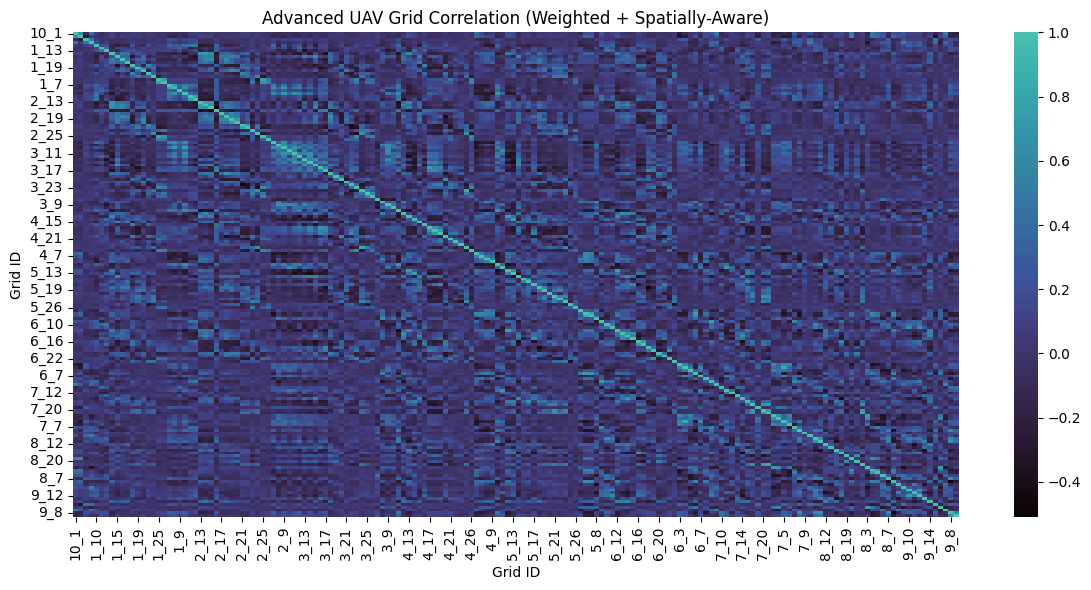


📊 Improved Combined Correlation Matrix:
       10_1   10_2   11_1   11_2   1_10   1_11   1_13   1_14   1_15   1_16  \
10_1  1.000  0.649 -0.077  0.424  0.077 -0.057 -0.002  0.097 -0.038  0.016   
10_2  0.649  1.000 -0.287  0.047 -0.024 -0.037  0.022  0.151 -0.003  0.089   
11_1 -0.077 -0.287  1.000  0.462  0.093 -0.006  0.019 -0.047 -0.020 -0.060   
11_2  0.424  0.047  0.462  1.000  0.184 -0.012  0.069 -0.015 -0.068 -0.049   
1_10  0.077 -0.024  0.093  0.184  1.000  0.146  0.202 -0.150 -0.221 -0.140   
...     ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
9_2  -0.127 -0.337  0.458  0.435  0.131  0.092  0.087 -0.085 -0.022 -0.073   
9_3   0.016  0.113 -0.105 -0.223 -0.079 -0.013 -0.065  0.111  0.140  0.063   
9_4   0.478  0.312  0.035  0.416  0.171 -0.040  0.019  0.018 -0.076 -0.010   
9_8  -0.143 -0.190  0.231  0.126  0.176  0.225  0.193 -0.178 -0.047 -0.081   
9_9  -0.180 -0.137  0.121 -0.046 -0.032  0.206  0.110 -0.129  0.087 -0.035   

      ...   9_10   9_1

In [24]:
import pandas as pd
import numpy as np
from scipy.stats import mode, spearmanr, kendalltau, skew, kurtosis, linregress
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import dcor

# ==========================
# Fill missing RSRP
# ==========================
df['Serving RSRP_4G'] = (
    df['Serving RSRP_4G']
    .interpolate(method='linear')
    .fillna(method='bfill')
    .fillna(method='ffill')
)

# ==========================
# Feature creation with extended stats
# ==========================
def create_rsrp_features(grid_df):
    rsrp = grid_df['Serving RSRP_4G'].dropna().values
    if len(rsrp) < 3:
        return np.zeros(11)

    rsrp_mean = np.mean(rsrp)
    rsrp_median = np.median(rsrp)
    try:
        rsrp_mode = pd.Series(rsrp).mode().iloc[0]
    except Exception:
        rsrp_mode = rsrp_mean

    rsrp_std = np.std(rsrp)
    rsrp_min = np.min(rsrp)
    rsrp_max = np.max(rsrp)
    rsrp_range = rsrp_max - rsrp_min

    # New features
    rsrp_skew = skew(rsrp)
    rsrp_kurt = kurtosis(rsrp)
    rsrp_diff_std = np.std(np.diff(rsrp))
    rsrp_slope = linregress(range(len(rsrp)), rsrp).slope

    return np.array([
        rsrp_mean, rsrp_median, rsrp_mode, rsrp_std, rsrp_min, rsrp_max,
        rsrp_range, rsrp_skew, rsrp_kurt, rsrp_diff_std, rsrp_slope
    ])

# ==========================
# Group by grid and compute features
# ==========================
df['grid_id'] = df['lat_bin'].astype(str) + "_" + df['lon_bin'].astype(str)
grid_groups = df.groupby('grid_id')

grid_features = []
grid_ids = []
grid_centers = []

for gid, group in grid_groups:
    grid_features.append(create_rsrp_features(group))
    grid_ids.append(gid)
    grid_centers.append([group['Latitude'].mean(), group['Longitude'].mean()])

features = np.array(grid_features)
grid_centers = np.array(grid_centers)
grid_ids = np.array(grid_ids)

# Select first N grids
N = 170
features_n = features[:N]
grid_ids_n = grid_ids[:N]
centers_n = grid_centers[:N]

# ==========================
# Standardize
# ==========================
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_n)

# ==========================
# Correlations
# ==========================
pearson_corr = np.corrcoef(features_scaled, rowvar=True)

spearman_corr = np.zeros_like(pearson_corr)
kendall_corr = np.zeros_like(pearson_corr)
dist_corr = np.zeros_like(pearson_corr)

for i in range(N):
    for j in range(N):
        spearman_corr[i, j] = spearmanr(features_scaled[i], features_scaled[j]).correlation
        kendall_corr[i, j] = kendalltau(features_scaled[i], features_scaled[j]).correlation
        dist_corr[i, j] = dcor.distance_correlation(features_scaled[i], features_scaled[j])

# ==========================
# Spatial weighting
# ==========================
from scipy.spatial.distance import cdist
geo_dist = cdist(centers_n, centers_n, metric='euclidean')
spatial_weight = np.exp(-geo_dist / np.mean(geo_dist))

# ==========================
# Weighted correlation fusion
# ==========================
combined_corr = (
    0.4 * pearson_corr +
    0.3 * spearman_corr +
    0.2 * dist_corr +
    0.1 * kendall_corr
) * spatial_weight

# ==========================
# Visualization
# ==========================
corr_df = pd.DataFrame(combined_corr, index=grid_ids_n, columns=grid_ids_n)
plt.figure(figsize=(12, 6))
sns.heatmap(corr_df, cmap='mako', annot=False, center=0.5)
plt.title("Advanced UAV Grid Correlation (Weighted + Spatially-Aware)")
plt.xlabel("Grid ID")
plt.ylabel("Grid ID")
plt.tight_layout()
plt.show()

print("\n📊 Improved Combined Correlation Matrix:")
print(corr_df.round(3))

# Optional: list top correlated pairs
pairs = []
for i in range(N):
    for j in range(i + 1, N):
        pairs.append((grid_ids_n[i], grid_ids_n[j], combined_corr[i, j]))
top_pairs = sorted(pairs, key=lambda x: x[2], reverse=True)[:10]
print("\n🔝 Top 10 Most Correlated Grid Pairs:")
for g1, g2, corr in top_pairs:
    print(f"{g1} ↔ {g2} : {corr:.3f}")
# ==========================
# Save Full Correlation Matrix to CSV
# ==========================

output_path = "uav_grid_correlation_matrix.csv"
corr_df.to_csv(output_path, index=True)

print(f"\n💾 Correlation matrix saved successfully as: {output_path}")
print(f"Matrix shape: {corr_df.shape}")


✅ Bipartite Graph Created Successfully!
Total Nodes: 340
Total Edges: 28900

Top 10 Strongest Correlations:
11_2 ↔ 11_2_R  →  Weight: 1.0000
1_14 ↔ 1_14_R  →  Weight: 1.0000
1_20 ↔ 1_20_R  →  Weight: 1.0000
1_9 ↔ 1_9_R  →  Weight: 1.0000
2_15 ↔ 2_15_R  →  Weight: 1.0000
3_10 ↔ 3_10_R  →  Weight: 1.0000
3_14 ↔ 3_14_R  →  Weight: 1.0000
3_7 ↔ 3_7_R  →  Weight: 1.0000
4_10 ↔ 4_10_R  →  Weight: 1.0000
4_12 ↔ 4_12_R  →  Weight: 1.0000


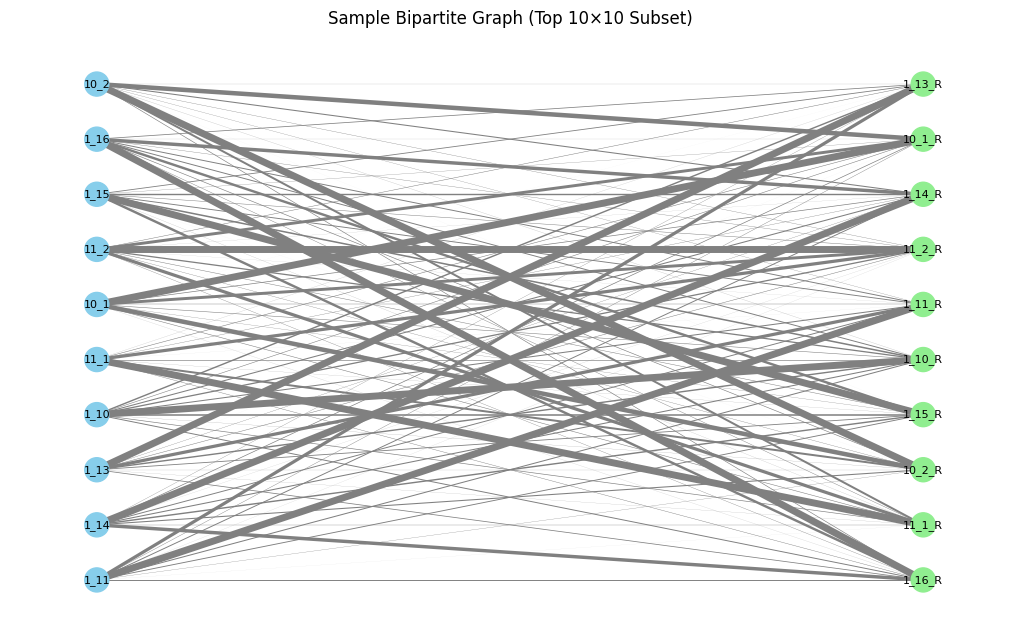

In [25]:
import pandas as pd
import networkx as nx

# ==========================
# 1️⃣ Load Correlation Matrix
# ==========================
corr_df = pd.read_csv("uav_grid_correlation_matrix.csv", index_col=0)

# ==========================
# 2️⃣ Create Complete Bipartite Graph
# ==========================
G = nx.Graph()

# Define the two node sets
U = list(corr_df.index)     # Left set
V = [f"{node}_R" for node in corr_df.columns]  # Right set (rename to avoid overlap)

# Add nodes with bipartite attribute
G.add_nodes_from(U, bipartite=0)
G.add_nodes_from(V, bipartite=1)

# ==========================
# 3️⃣ Add Weighted Edges
# ==========================
for i, u in enumerate(U):
    for j, v in enumerate(V):
        weight = corr_df.iloc[i, j]
        if not pd.isna(weight):  # Skip NaNs if any
            G.add_edge(u, v, weight=weight)

print(f"✅ Bipartite Graph Created Successfully!")
print(f"Total Nodes: {G.number_of_nodes()}")
print(f"Total Edges: {G.number_of_edges()}")

# ==========================
# 4️⃣ Optional: Analyze Graph
# ==========================
# Get top weighted edges
top_edges = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:10]
print("\nTop 10 Strongest Correlations:")
for u, v, d in top_edges:
    print(f"{u} ↔ {v}  →  Weight: {d['weight']:.4f}")

# ==========================
# 5️⃣ Optional: Visualize Small Subgraph
# ==========================
import matplotlib.pyplot as plt

# Take first 10 nodes from each set for visualization
sub_U = U[:10]
sub_V = V[:10]
sub_nodes = sub_U + sub_V
sub_G = G.subgraph(sub_nodes)

pos = nx.bipartite_layout(sub_G, sub_U)
weights = [d['weight'] for (_, _, d) in sub_G.edges(data=True)]

plt.figure(figsize=(10, 6))
nx.draw(sub_G, pos, with_labels=True, node_color=['skyblue' if n in sub_U else 'lightgreen' for n in sub_G],
        width=[abs(w)*5 for w in weights], edge_color='gray', font_size=8)
plt.title("Sample Bipartite Graph (Top 10×10 Subset)")
plt.show()


In [26]:
!pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.4 MB/s eta 0:00:00


In [27]:
import pandas as pd
import networkx as nx
from pyvis.network import Network

# 1️⃣ Load Correlation Matrix
corr_df = pd.read_csv("/content/uav_grid_correlation_matrix.csv", index_col=0)

# 2️⃣ Create Bipartite Graph
G = nx.Graph()
U = list(corr_df.index)
V = [f"{node}_R" for node in corr_df.columns]

G.add_nodes_from(U, bipartite=0)
G.add_nodes_from(V, bipartite=1)

for i, u in enumerate(U):
    for j, v in enumerate(V):
        weight = corr_df.iloc[i, j]
        if not pd.isna(weight):
            G.add_edge(u, v, weight=weight)

print(f"✅ Bipartite Graph Created!")
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

# 3️⃣ Create Interactive Visualization
net = Network(height="750px", width="100%", bgcolor="#ffffff", font_color="black", notebook=False)

# Add nodes
for node in U:
    net.add_node(node, label=node, color="skyblue", title=f"Grid: {node}")

for node in V:
    net.add_node(node, label=node, color="lightgreen", title=f"Grid: {node}")

# Add edges
for u, v, data in G.edges(data=True):
    w = data["weight"]
    net.add_edge(u, v, value=w, title=f"Correlation: {w:.4f}", color="gray")

# Save interactive HTML
net.write_html("bipartite_correlation_graph.html")
print("🌐 Interactive graph saved as 'bipartite_correlation_graph.html'")
print("➡ Open it in your browser to hover and view correlation values.")

# 4️⃣ Create Bipartite Weight Matrix
bipartite_matrix = pd.DataFrame(index=U, columns=V)

for u in U:
    for v in V:
        bipartite_matrix.loc[u, v] = G[u][v]["weight"] if G.has_edge(u, v) else 0

print("\n📊 Bipartite Graph Weight Matrix (sample):")
print(bipartite_matrix.iloc[:10, :10].round(3))

✅ Bipartite Graph Created!
Nodes: 340, Edges: 28900
🌐 Interactive graph saved as 'bipartite_correlation_graph.html'
➡ Open it in your browser to hover and view correlation values.

📊 Bipartite Graph Weight Matrix (sample):
        10_1_R    10_2_R    11_1_R    11_2_R    1_10_R    1_11_R    1_13_R  \
10_1       1.0  0.648678 -0.076602  0.424218  0.076662  -0.05718 -0.002372   
10_2  0.648678       1.0 -0.287473  0.047001 -0.023905 -0.037491  0.022184   
11_1 -0.076602 -0.287473       1.0  0.461619  0.093059 -0.005742  0.019199   
11_2  0.424218  0.047001  0.461619       1.0  0.183718 -0.012079  0.068578   
1_10  0.076662 -0.023905  0.093059  0.183718       1.0  0.146292  0.201864   
1_11  -0.05718 -0.037491 -0.005742 -0.012079  0.146292       1.0  0.461836   
1_13 -0.002372  0.022184  0.019199  0.068578  0.201864  0.461836       1.0   
1_14  0.097152   0.15146 -0.047256 -0.014757  -0.15047  -0.13743 -0.041558   
1_15 -0.037621 -0.002754 -0.019753 -0.067623 -0.221047  0.132238 -0.120375 

In [28]:
import pandas as pd
import numpy as np

# ==========================
# Step 1: Load correlation matrix
# ==========================
corr_df = pd.read_csv("uav_grid_correlation_matrix.csv", index_col=0)
print(corr_df.shape)
active_nodes = list(corr_df.columns)
corr_matrix = corr_df.loc[active_nodes, active_nodes].values.copy()

threshold = 0.7  # correlation cutoff
master_slave_map = {}  # store mapping as {master: [slaves]}
iteration = 1

# ==========================
# Step 2: Iteratively select Master–Slave groups
# ==========================
while len(active_nodes) > 0:
    print(f"\n========== ITERATION {iteration} ==========")

    # Compute sum of correlations for each active node
    total_corr = np.sum(corr_matrix, axis=1) - np.diag(corr_matrix)

    # Select node with max total correlation → Master
    master_idx = np.argmax(total_corr)
    master_node = active_nodes[master_idx]

    # Find all slave nodes with correlation > threshold
    slave_indices = np.where(corr_matrix[master_idx] > threshold)[0]
    slave_indices = [i for i in slave_indices if i != master_idx]

    slave_nodes = [active_nodes[i] for i in slave_indices]

    # Store mapping
    master_slave_map[master_node] = slave_nodes
    print(f"MASTER: {master_node}")
    print(f"SLAVES ({len(slave_nodes)}): {', '.join(slave_nodes) if slave_nodes else 'None'}")
    print("-" * 50)

    # Remove master + slaves from active nodes and matrix
    remove_indices = sorted([master_idx] + slave_indices, reverse=True)
    for idx in remove_indices:
        corr_matrix = np.delete(corr_matrix, idx, axis=0)
        corr_matrix = np.delete(corr_matrix, idx, axis=1)
        del active_nodes[idx]

    iteration += 1

# ==========================
# Step 3: Print summary
# ==========================
total_masters = len(master_slave_map)
total_slaves = sum(len(slaves) for slaves in master_slave_map.values())
print(f"\n✅ Total Master Nodes: {total_masters}")
print(f"✅ Total Slave Nodes: {total_slaves}")

# ==========================
# Step 4: Save to CSV properly
# ==========================
output = []
for master, slaves in master_slave_map.items():
    if not slaves:
        output.append([master, ""])
    else:
        # Join all slave names into a single comma-separated string
        output.append([master, ",".join(slaves)])

output_df = pd.DataFrame(output, columns=["Master_Node", "Slave_Nodes"])
output_df.to_csv("master_slave_mapping.csv", index=False)
print("\n✅ CSV saved correctly with all slave nodes for each master!")


(170, 170)

========== ITERATION 1 ==========
MASTER: 4_15
SLAVES (0): None
--------------------------------------------------

========== ITERATION 2 ==========
MASTER: 6_14
SLAVES (1): 7_14
--------------------------------------------------

========== ITERATION 3 ==========
MASTER: 3_12
SLAVES (0): None
--------------------------------------------------

========== ITERATION 4 ==========
MASTER: 2_14
SLAVES (2): 1_14, 2_13
--------------------------------------------------

========== ITERATION 5 ==========
MASTER: 2_9
SLAVES (1): 2_10
--------------------------------------------------

========== ITERATION 6 ==========
MASTER: 7_15
SLAVES (0): None
--------------------------------------------------

========== ITERATION 7 ==========
MASTER: 8_11
SLAVES (0): None
--------------------------------------------------

========== ITERATION 8 ==========
MASTER: 5_19
SLAVES (0): None
--------------------------------------------------

========== ITERATION 9 ==========
MASTER: 7_7
SLAVES (0

In [29]:
df.head()

,No.,Longitude,Latitude,Serving RSRP_4G,lat_bin,lon_bin,grid_centroid_lat,grid_centroid_lon,grid_id
0,1,3.502389,6.437201,-62.50,4,26,6.438496,3.503567,4_26
1,2,3.502389,6.437201,-65.69,4,26,6.438496,3.503567,4_26
2,3,3.502389,6.437201,-65.38,4,26,6.438496,3.503567,4_26
3,4,3.502389,6.437201,-61.81,4,26,6.438496,3.503567,4_26
4,5,3.502389,6.437201,-65.06,4,26,6.438496,3.503567,4_26


In [30]:
import pandas as pd

# ==========================================================
# INPUT DATA
# ==========================================================
# df = pd.read_csv("your_full_dataset.csv")

# Required columns:
# grid_id, grid_centroid_lat, grid_centroid_lon

# ==========================================================
# STEP 1 — EXTRACT UNIQUE GRID CENTROIDS
# ==========================================================
grid_centroid_df = (
    df[['grid_id', 'grid_centroid_lat', 'grid_centroid_lon']]
    .drop_duplicates()
    .sort_values('grid_id')
    .reset_index(drop=True)
)

# ==========================================================
# STEP 2 — BASIC VALIDATION
# ==========================================================
print("Total Unique Grids:", len(grid_centroid_df))
print(grid_centroid_df.head())

# ==========================================================
# STEP 3 — SAVE FOR TSP USE
# ==========================================================
grid_centroid_df.to_csv("grid_centroids.csv", index=False)

print("\n✅ grid_centroids.csv created successfully!")

Total Unique Grids: 170
  grid_id  grid_centroid_lat  grid_centroid_lon
0    10_1           6.468496           3.378567
1    10_2           6.468496           3.383567
2    11_1           6.473496           3.378567
3    11_2           6.473496           3.383567
4    1_10           6.423496           3.423567

✅ grid_centroids.csv created successfully!


In [31]:
import pandas as pd
import numpy as np
import networkx as nx
import folium
from math import cos, radians, sqrt
from networkx.algorithms.approximation import traveling_salesman_problem
from networkx.algorithms.approximation.traveling_salesman import greedy_tsp

# ==========================================================
# STEP 1 — LOAD MASTER NODES
# ==========================================================
master_df = pd.read_csv("master_slave_mapping.csv")
master_nodes = master_df["Master_Node"].tolist()

print(f"Total Master Nodes Used for TSP: {len(master_nodes)}")

# ==========================================================
# STEP 2 — LOAD CENTROID DATA
# ==========================================================
# Must contain: grid_id, grid_centroid_lat, grid_centroid_lon
centroid_df = pd.read_csv("grid_centroids.csv")

# Keep only MASTER grids
master_centroids = centroid_df[
    centroid_df["grid_id"].isin(master_nodes)
].reset_index(drop=True)

# ==========================================================
# STEP 3 — CONVERT LAT/LON → PLANAR KM (EUCLIDEAN SAFE)
# ==========================================================
lat0 = master_centroids["grid_centroid_lat"].mean()
lon0 = master_centroids["grid_centroid_lon"].mean()

def latlon_to_xy_km(lat, lon, lat0, lon0):
    x = (lon - lon0) * 111.32 * cos(radians(lat0))
    y = (lat - lat0) * 110.574
    return x, y

master_centroids[["x_km", "y_km"]] = master_centroids.apply(
    lambda r: latlon_to_xy_km(
        r["grid_centroid_lat"],
        r["grid_centroid_lon"],
        lat0,
        lon0
    ),
    axis=1,
    result_type="expand"
)

# ==========================================================
# STEP 4 — BUILD COMPLETE GRAPH (MASTER GRIDS ONLY)
# ==========================================================
def euclidean_km(p1, p2):
    return sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

G = nx.complete_graph(len(master_centroids))

for i, row in master_centroids.iterrows():
    G.nodes[i]["pos"] = (row["x_km"], row["y_km"])
    G.nodes[i]["latlon"] = (row["grid_centroid_lat"], row["grid_centroid_lon"])
    G.nodes[i]["grid_id"] = row["grid_id"]

for i in G.nodes:
    for j in G.nodes:
        if i != j:
            G[i][j]["weight"] = euclidean_km(
                G.nodes[i]["pos"],
                G.nodes[j]["pos"]
            )

# ==========================================================
# STEP 5 — TSP ON MASTER GRIDS ONLY (FIXED)
# ==========================================================
tsp_path = traveling_salesman_problem(
    G,
    weight="weight",
    cycle=True,
    method=greedy_tsp   # ✅ FIXED
)

# ==========================================================
# STEP 6 — OPTIMAL DISTANCE (KM)
# ==========================================================
optimal_distance_km = sum(
    G[tsp_path[i]][tsp_path[i + 1]]["weight"]
    for i in range(len(tsp_path) - 1)
)

ordered_master_grids = [G.nodes[i]["grid_id"] for i in tsp_path]

print("\nOptimal Master Grid Visit Order:")
print(ordered_master_grids)

print(f"\n✅ Optimal TSP Distance (Masters Only): {optimal_distance_km:.3f} KM")

# ==========================================================
# STEP 7 — FOLIUM VISUALIZATION (MASTER TSP PATH)
# ==========================================================
m = folium.Map(
    location=[
        master_centroids["grid_centroid_lat"].mean(),
        master_centroids["grid_centroid_lon"].mean()
    ],
    zoom_start=13
)

# Plot master nodes
for i, row in master_centroids.iterrows():
    folium.CircleMarker(
        location=[row["grid_centroid_lat"], row["grid_centroid_lon"]],
        radius=5,
        color="red",
        fill=True,
        fill_opacity=0.9,
        popup=f"Master Grid: {row['grid_id']}"
    ).add_to(m)

# Plot TSP optimal path
tsp_coords = [G.nodes[i]["latlon"] for i in tsp_path]

folium.PolyLine(
    tsp_coords,
    color="blue",
    weight=4,
    opacity=0.85,
    tooltip="Master Grid TSP Path"
).add_to(m)

# Start / End marker
start_node = tsp_path[0]
folium.Marker(
    location=G.nodes[start_node]["latlon"],
    popup="Start / End Master Grid",
    icon=folium.Icon(color="green")
).add_to(m)

m

Total Master Nodes Used for TSP: 144

Optimal Master Grid Visit Order:
['10_1', '9_1', '8_1', '7_1', '7_2', '8_2', '9_2', '10_2', '11_2', '11_1', '9_3', '9_4', '8_4', '7_4', '7_3', '6_3', '6_5', '5_5', '5_6', '4_6', '4_7', '3_7', '2_7', '2_8', '1_8', '1_9', '2_9', '3_9', '4_9', '4_8', '3_8', '5_8', '6_8', '7_8', '8_8', '9_8', '9_9', '8_9', '7_9', '6_9', '6_10', '5_10', '4_10', '3_10', '3_11', '2_11', '1_11', '1_10', '3_12', '4_12', '5_12', '5_11', '6_11', '7_12', '8_12', '9_12', '9_11', '8_11', '8_10', '7_10', '7_13', '8_13', '9_13', '9_14', '8_14', '8_15', '7_15', '6_15', '5_15', '4_15', '3_15', '2_15', '1_15', '1_16', '2_16', '2_17', '1_17', '1_18', '2_18', '3_18', '4_18', '5_18', '6_18', '6_17', '5_17', '4_17', '3_17', '4_16', '5_16', '6_16', '6_14', '5_14', '4_14', '3_14', '2_14', '1_13', '3_13', '6_13', '6_19', '5_19', '5_20', '6_20', '7_20', '8_20', '8_19', '7_19', '6_21', '5_21', '4_21', '3_21', '2_21', '1_22', '2_23', '3_23', '4_23', '5_23', '5_22', '6_22', '4_22', '3_22', '3_2

# Start Nodes Are Random In Meta Heuresic Algos

In [76]:
import pandas as pd
import numpy as np
import networkx as nx
import folium
from math import cos, radians, sqrt

# ==========================================================
# STEP 1 — LOAD MASTER NODES
# ==========================================================
master_df = pd.read_csv("master_slave_mapping.csv")
master_nodes = master_df["Master_Node"].tolist()
print(f"Total Master Nodes Used for ACO-TSP: {len(master_nodes)}")

# ==========================================================
# STEP 2 — LOAD CENTROID DATA
# ==========================================================
# Must contain: grid_id, grid_centroid_lat, grid_centroid_lon
centroid_df = pd.read_csv("grid_centroids.csv")

# Keep ONLY master grids
master_centroids = centroid_df[
    centroid_df["grid_id"].isin(master_nodes)
].reset_index(drop=True)

# ==========================================================
# STEP 3 — LAT/LON → PLANAR KM (EUCLIDEAN SAFE)
# ==========================================================
lat0 = master_centroids["grid_centroid_lat"].mean()
lon0 = master_centroids["grid_centroid_lon"].mean()

def latlon_to_xy_km(lat, lon, lat0, lon0):
    x = (lon - lon0) * 111.32 * cos(radians(lat0))
    y = (lat - lat0) * 110.574
    return x, y

master_centroids[["x_km", "y_km"]] = master_centroids.apply(
    lambda r: latlon_to_xy_km(
        r["grid_centroid_lat"],
        r["grid_centroid_lon"],
        lat0,
        lon0
    ),
    axis=1,
    result_type="expand"
)

# ==========================================================
# STEP 4 — DISTANCE MATRIX (EUCLIDEAN KM)
# ==========================================================
def euclidean_km(p1, p2):
    return sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

coords = master_centroids[["x_km", "y_km"]].values
n_nodes = len(coords)

distance_matrix = np.zeros((n_nodes, n_nodes))
for i in range(n_nodes):
    for j in range(n_nodes):
        if i != j:
            distance_matrix[i, j] = euclidean_km(coords[i], coords[j])
        else:
            distance_matrix[i, j] = np.inf

# ==========================================================
# STEP 5 — ACO PARAMETERS
# ==========================================================
np.random.seed(42)

n_ants = n_nodes          # ✔ ants = master nodes
# n_iterations = 100
n_iterations = 50       # ✔ as requested
alpha = 1.0               # pheromone importance
beta = 2.0                # distance importance
evaporation = 0.5
Q = 1.0

pheromone = np.ones((n_nodes, n_nodes))
best_path = None
best_distance = np.inf

# ==========================================================
# STEP 6 — ACO MAIN LOOP
# ==========================================================
for iteration in range(n_iterations):
    for ant in range(n_ants):
        start = ant % n_nodes
        path = [start]
        visited = set(path)

        while len(visited) < n_nodes:
            current = path[-1]
            unvisited = list(set(range(n_nodes)) - visited)

            probs = []
            for j in unvisited:
                tau = pheromone[current, j] ** alpha
                eta = (1 / distance_matrix[current, j]) ** beta
                probs.append(tau * eta)

            probs = np.array(probs)
            probs /= probs.sum()

            next_node = np.random.choice(unvisited, p=probs)
            path.append(next_node)
            visited.add(next_node)

        # close tour
        path.append(start)

        dist = sum(
            distance_matrix[path[i], path[i + 1]]
            for i in range(len(path) - 1)
        )

        if dist < best_distance:
            best_distance = dist
            best_path = path

        # pheromone update (local)
        for i in range(len(path) - 1):
            pheromone[path[i], path[i + 1]] += Q / dist
            pheromone[path[i + 1], path[i]] += Q / dist

    # evaporation
    pheromone *= (1 - evaporation)

    print(f"Iteration {iteration + 1}/{n_iterations} — Best Distance: {best_distance:.3f} km")

# ==========================================================
# STEP 7 — FINAL RESULTS
# ==========================================================
ordered_master_grids = [
    master_centroids.iloc[i]["grid_id"] for i in best_path
]

print("\n🐜 ACO Optimal Master Grid Order:")
print(ordered_master_grids)

print(f"\n✅ ACO Optimal Distance (KM): {best_distance:.3f}")

# ==========================================================
# STEP 8 — FOLIUM VISUALIZATION (ACO PATH)
# ==========================================================
m = folium.Map(
    location=[
        master_centroids["grid_centroid_lat"].mean(),
        master_centroids["grid_centroid_lon"].mean()
    ],
    zoom_start=13
)

# plot master nodes
for i, row in master_centroids.iterrows():
    folium.CircleMarker(
        location=[row["grid_centroid_lat"], row["grid_centroid_lon"]],
        radius=5,
        color="red",
        fill=True,
        fill_opacity=0.9,
        popup=f"Master Grid: {row['grid_id']}"
    ).add_to(m)

# plot ACO optimal path
aco_coords = [
    (
        master_centroids.iloc[i]["grid_centroid_lat"],
        master_centroids.iloc[i]["grid_centroid_lon"]
    )
    for i in best_path
]

folium.PolyLine(
    aco_coords,
    color="purple",
    weight=4,
    opacity=0.85,
    tooltip="ACO-TSP Optimal Master Path"
).add_to(m)

# start / end marker
folium.Marker(
    location=aco_coords[0],
    popup="Start / End",
    icon=folium.Icon(color="green")
).add_to(m)

m


Total Master Nodes Used for ACO-TSP: 144
Iteration 1/50 — Best Distance: 229.247 km
Iteration 2/50 — Best Distance: 212.948 km
Iteration 3/50 — Best Distance: 204.127 km
Iteration 4/50 — Best Distance: 176.301 km
Iteration 5/50 — Best Distance: 159.192 km
Iteration 6/50 — Best Distance: 134.756 km
Iteration 7/50 — Best Distance: 124.840 km
Iteration 8/50 — Best Distance: 105.412 km
Iteration 9/50 — Best Distance: 105.412 km
Iteration 10/50 — Best Distance: 105.412 km
Iteration 11/50 — Best Distance: 105.412 km
Iteration 12/50 — Best Distance: 105.412 km
Iteration 13/50 — Best Distance: 105.412 km
Iteration 14/50 — Best Distance: 105.412 km
Iteration 15/50 — Best Distance: 105.412 km
Iteration 16/50 — Best Distance: 104.147 km
Iteration 17/50 — Best Distance: 101.260 km
Iteration 18/50 — Best Distance: 101.260 km
Iteration 19/50 — Best Distance: 101.260 km
Iteration 20/50 — Best Distance: 101.260 km
Iteration 21/50 — Best Distance: 101.260 km
Iteration 22/50 — Best Distance: 101.260 km


In [77]:
tsp_coords = [G.nodes[i]["latlon"] for i in tsp_path]

folium.PolyLine(
    tsp_coords,
    color="purple",
    weight=4,
    opacity=0.85,
    tooltip="ACO-TSP Optimal UAV Path"
).add_to(m)
m

In [78]:
# ==========================================================
# STEP 9 — ENERGY / COST CALCULATION FOR GIVEN PATH
# ==========================================================

import math

# ---------- PARAMETERS ----------
UAV_SPEED = 2.0          # m/s
CRUISE_POWER = 308.709   # Watts
TURN_COEFF = 225
TURN_REF = 2.1
CORRECTION = -0.852

# coords currently in KM → convert to meters
coords_m = coords * 1000


# ==========================================================
# ANGLE FUNCTION
# ==========================================================
def deviation_angle(p_prev, p_curr, p_next):
    vA = p_prev - p_curr
    vB = p_next - p_curr

    magA = np.linalg.norm(vA)
    magB = np.linalg.norm(vB)

    if magA == 0 or magB == 0:
        return 0.0

    cos_theta = np.clip(np.dot(vA, vB) / (magA * magB), -1, 1)
    angle = math.acos(cos_theta)   # radians

    return angle


# ==========================================================
# TOTAL ENERGY / COST
# ==========================================================
total_energy = 0.0
total_distance_m = 0.0

# First segment (distance only)
p0 = coords_m[best_path[0]]
p1 = coords_m[best_path[1]]

dist = np.linalg.norm(p1 - p0)
time = dist / UAV_SPEED
total_energy += CRUISE_POWER * time + CORRECTION
total_distance_m += dist

# Remaining segments
for i in range(1, len(best_path) - 1):
    p_prev = coords_m[best_path[i - 1]]
    p_curr = coords_m[best_path[i]]
    p_next = coords_m[best_path[i + 1]]

    # Distance energy
    dist = np.linalg.norm(p_next - p_curr)
    time = dist / UAV_SPEED
    E_dist = CRUISE_POWER * time + CORRECTION

    # Turn energy
    angle = deviation_angle(p_prev, p_curr, p_next)
    E_turn = TURN_COEFF * (angle / TURN_REF)

    total_energy += E_dist + E_turn
    total_distance_m += dist


# ==========================================================
# RESULTS
# ==========================================================
total_distance_km = total_distance_m / 1000
energy_wh = total_energy / 3600

print("\n====================================")
print("PATH ENERGY / COST ANALYSIS")
print("====================================")
print("Nodes Visited        :", len(best_path)-1)
print("Total Distance (km)  :", round(total_distance_km, 3))
print("Total Distance (m)   :", round(total_distance_m, 2))
print("Total Energy/Cost (J):", round(total_energy, 2))
print("Energy (Wh)          :", round(energy_wh, 2))
print("====================================\n")



PATH ENERGY / COST ANALYSIS
Nodes Visited        : 144
Total Distance (km)  : 97.679
Total Distance (m)   : 97678.73
Total Energy/Cost (J): 15107246.05
Energy (Wh)          : 4196.46



In [67]:
# ==========================================================
# STEP 9 — ENERGY CALCULATION FOR ACO DISTANCE PATH
# ==========================================================

import math

# ---------- UAV PARAMETERS ----------
UAV_SPEED = 2.0        # m/s
CRUISE_POWER = 308.709 # Watts
TURN_COEFF = 225
TURN_REF = 2.1
CORRECTION = -0.852

# Convert coordinates from KM → meters
points_m = coords * 1000


# ---------- TURN ANGLE FUNCTION ----------
def deviation_angle(p_prev, p_curr, p_next):
    vA = p_prev - p_curr
    vB = p_next - p_curr

    magA = np.linalg.norm(vA)
    magB = np.linalg.norm(vB)

    if magA == 0 or magB == 0:
        return 0.0

    cos_theta = np.clip(np.dot(vA, vB) / (magA * magB), -1, 1)
    angle = math.degrees(math.acos(cos_theta))

    return min(angle, 360 - angle)


# ---------- STEP ENERGY ----------
def step_energy(p_prev, p_curr, p_next):
    # Distance energy
    dist = np.linalg.norm(p_next - p_curr)
    time = dist / UAV_SPEED
    E_dist = CRUISE_POWER * time + CORRECTION

    # Turn energy
    angle = deviation_angle(p_prev, p_curr, p_next)
    E_turn = TURN_COEFF * (math.radians(angle) / TURN_REF) if angle > 0 else 0

    return E_dist + E_turn


# ---------- TOTAL ENERGY ----------
total_energy = 0.0

# First segment (distance only)
p0 = points_m[best_path[0]]
p1 = points_m[best_path[1]]
dist = np.linalg.norm(p1 - p0)
time = dist / UAV_SPEED
total_energy += CRUISE_POWER * time + CORRECTION

# Remaining segments
for i in range(1, len(best_path)-1):
    p_prev = points_m[best_path[i-1]]
    p_curr = points_m[best_path[i]]
    p_next = points_m[best_path[i+1]]

    total_energy += step_energy(p_prev, p_curr, p_next)


# ---------- DISTANCE ----------
total_distance_km = best_distance
total_distance_m = best_distance * 1000

# ---------- CONVERT TO Wh ----------
energy_wh = total_energy / 3600


# ---------- OUTPUT ----------
print("\n======================================")
print("ACO (Distance-Based) Path Energy")
print("======================================")
print(f"Nodes Visited        : {len(best_path)-1}")
print(f"Total Distance (km)  : {total_distance_km:.3f}")
print(f"Total Distance (m)   : {total_distance_m:.2f}")
print(f"Total Energy (J)     : {total_energy:.2f}")
print(f"Energy (Wh)          : {energy_wh:.2f}")
print("======================================\n")



ACO (Distance-Based) Path Energy
Nodes Visited        : 144
Total Distance (km)  : 97.679
Total Distance (m)   : 97678.73
Total Energy (J)     : 15107246.05
Energy (Wh)          : 4196.46



In [34]:
# ==========================================================
# STEP 9 — PATH METRICS WINDOW (DISTANCE + ENERGY)
# ==========================================================

import math

# ---------- UAV PARAMETERS ----------
UAV_SPEED = 2.0        # m/s
CRUISE_POWER = 308.709 # Watts
TURN_COEFF = 225
TURN_REF = 2.1
CORRECTION = -0.852


# ---------- CONVERT COORDINATES ----------
# coords are in KM → convert to meters
points_m = coords * 1000


# ---------- ANGLE FUNCTION ----------
def deviation_angle(p_prev, p_curr, p_next):
    vA = p_prev - p_curr
    vB = p_next - p_curr

    magA = np.linalg.norm(vA)
    magB = np.linalg.norm(vB)

    if magA == 0 or magB == 0:
        return 0.0

    cos_theta = np.clip(np.dot(vA, vB) / (magA * magB), -1, 1)
    angle = math.degrees(math.acos(cos_theta))

    return min(angle, 360 - angle)


# ---------- STEP ENERGY ----------
def step_energy(p_prev, p_curr, p_next):
    dist = np.linalg.norm(p_next - p_curr)
    time = dist / UAV_SPEED
    E_dist = CRUISE_POWER * time + CORRECTION

    angle = deviation_angle(p_prev, p_curr, p_next)
    E_turn = TURN_COEFF * (math.radians(angle) / TURN_REF) if angle > 0 else 0

    return E_dist + E_turn


# ---------- TOTAL DISTANCE ----------
total_distance_km = 0.0
for i in range(len(best_path)-1):
    total_distance_km += distance_matrix[best_path[i], best_path[i+1]]

total_distance_m = total_distance_km * 1000


# ---------- TOTAL ENERGY ----------
total_energy = 0.0

# First segment (distance only)
p0 = points_m[best_path[0]]
p1 = points_m[best_path[1]]
dist = np.linalg.norm(p1 - p0)
time = dist / UAV_SPEED
total_energy += CRUISE_POWER * time + CORRECTION

# Remaining segments (distance + turn)
for i in range(1, len(best_path)-1):
    p_prev = points_m[best_path[i-1]]
    p_curr = points_m[best_path[i]]
    p_next = points_m[best_path[i+1]]

    total_energy += step_energy(p_prev, p_curr, p_next)


# Convert to Wh
energy_wh = total_energy / 3600


# ---------- OUTPUT WINDOW ----------
print("\n===================================")
print("ACO PATH PERFORMANCE")
print("===================================")
print(f"Nodes Visited        : {len(best_path)-1}")
print(f"Total Distance (km)  : {total_distance_km:.3f}")
print(f"Total Distance (m)   : {total_distance_m:.2f}")
print(f"Total Energy (J)     : {total_energy:.2f}")
print(f"Energy (Wh)          : {energy_wh:.2f}")
print("===================================\n")



ACO PATH PERFORMANCE
Nodes Visited        : 144
Total Distance (km)  : 97.679
Total Distance (m)   : 97678.73
Total Energy (J)     : 15107246.05
Energy (Wh)          : 4196.46



In [35]:
# # ==========================================================
# # TOTAL UAV ENERGY IN JOULES (SAFE, DISTANCE IN KM)
# # ==========================================================

# import numpy as np
# import math

# # ----------------------------------------------------------
# # PHYSICAL CONSTANTS (SI UNITS)
# # ----------------------------------------------------------
# UAV_SPEED = 2.0          # m/s
# CRUISE_POWER = 308.709   # Watts (J/s)
# TURN_COEFF = 225.0       # Joules per radian (turning effort)
# FIXED_HEIGHT = 60.0      # meters
# KM_TO_M = 1000.0

# # ----------------------------------------------------------
# # BUILD 3D POINTS (x_km, y_km, z_m)
# # ----------------------------------------------------------
# points_3d = np.array([
#     (row.x_km, row.y_km, FIXED_HEIGHT)
#     for _, row in master_centroids.iterrows()
# ])

# n_points = len(points_3d)

# # ----------------------------------------------------------
# # ANGLE CALCULATION (ROBUST)
# # ----------------------------------------------------------
# def deviation_angle(p_prev, p_curr, p_next):
#     vA = np.array(p_prev[:2]) - np.array(p_curr[:2])
#     vB = np.array(p_next[:2]) - np.array(p_curr[:2])

#     magA = np.linalg.norm(vA)
#     magB = np.linalg.norm(vB)

#     if magA == 0 or magB == 0:
#         return 0.0

#     cos_theta = np.clip(
#         np.dot(vA, vB) / (magA * magB),
#         -1.0,
#         1.0
#     )

#     return math.acos(cos_theta)  # radians

# # ----------------------------------------------------------
# # ENERGY COST FOR ONE MOVE (JOULES)
# # ----------------------------------------------------------
# def energy_cost_joules(p_prev, p_curr, p_next):
#     # distance in km (from coordinates)
#     dist_km = np.linalg.norm(p_next[:2] - p_curr[:2])

#     # convert km → meters
#     dist_m = dist_km * KM_TO_M

#     # flight time (seconds)
#     time_s = dist_m / UAV_SPEED

#     # cruise energy (J)
#     E_cruise = CRUISE_POWER * time_s

#     # turning energy (J)
#     angle_rad = deviation_angle(p_prev, p_curr, p_next)
#     E_turn = TURN_COEFF * angle_rad

#     return E_cruise + E_turn

# # ----------------------------------------------------------
# # TOTAL ENERGY OF A GIVEN PATH (SAFE)
# # ----------------------------------------------------------
# def total_energy_joules(points, path):
#     total_energy = 0.0
#     n_pts = len(points)

#     for i in range(len(path) - 2):
#         idx_prev = path[i]
#         idx_curr = path[i + 1]
#         idx_next = path[i + 2]

#         # ---- SAFETY CHECK ----
#         if (
#             idx_prev >= n_pts or
#             idx_curr >= n_pts or
#             idx_next >= n_pts
#         ):
#             continue

#         p_prev = points[idx_prev]
#         p_curr = points[idx_curr]
#         p_next = points[idx_next]

#         total_energy += energy_cost_joules(
#             p_prev, p_curr, p_next
#         )

#     return total_energy

# # ----------------------------------------------------------
# # CALCULATE ENERGY OF BEST PATH
# # ----------------------------------------------------------
# print("Max index in best_path:", max(best_path))
# print("Total available points:", n_points)

# total_energy_J = total_energy_joules(points_3d, best_path)

# print("\n⚡ Total UAV Energy (Joules):")
# print(f"   {total_energy_J:,.2f} J")


In [68]:
import pandas as pd
import numpy as np
import folium
from math import cos, radians, sqrt

# ==========================================================
# STEP 1 — LOAD MASTER NODES
# ==========================================================
master_df = pd.read_csv("master_slave_mapping.csv")
master_nodes = master_df["Master_Node"].tolist()

print(f"Total Master Nodes: {len(master_nodes)}")

# ==========================================================
# STEP 2 — LOAD FULL GRID DATASET
# ==========================================================
# Must contain:
# grid_id, grid_centroid_lat, grid_centroid_lon
centroid_df = pd.read_csv("grid_centroids.csv")

# Keep ONLY master grids
master_centroids = centroid_df[
    centroid_df["grid_id"].isin(master_nodes)
].reset_index(drop=True)

print("Master centroids loaded:", len(master_centroids))

# ==========================================================
# STEP 3 — LAT/LON → PLANAR KM (EUCLIDEAN SAFE)
# ==========================================================
lat0 = master_centroids["grid_centroid_lat"].mean()
lon0 = master_centroids["grid_centroid_lon"].mean()

def latlon_to_xy_km(lat, lon, lat0, lon0):
    x = (lon - lon0) * 111.32 * cos(radians(lat0))
    y = (lat - lat0) * 110.574
    return x, y

master_centroids[["x_km", "y_km"]] = master_centroids.apply(
    lambda r: latlon_to_xy_km(
        r["grid_centroid_lat"],
        r["grid_centroid_lon"],
        lat0,
        lon0
    ),
    axis=1,
    result_type="expand"
)

# ==========================================================
# STEP 4 — DISTANCE MATRIX (EUCLIDEAN KM)
# ==========================================================
coords = master_centroids[["x_km", "y_km"]].values
n_nodes = len(coords)

distance_matrix = np.zeros((n_nodes, n_nodes))

def euclidean_km(p1, p2):
    return sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

for i in range(n_nodes):
    for j in range(n_nodes):
        if i != j:
            distance_matrix[i, j] = euclidean_km(coords[i], coords[j])
        else:
            distance_matrix[i, j] = np.inf

# ==========================================================
# STEP 5 — INITIAL PATH (RANDOM)
# ==========================================================
np.random.seed(42)
path = list(range(n_nodes))
np.random.shuffle(path)
path.append(path[0])

def route_distance(route, dist):
    return sum(dist[route[i], route[i + 1]] for i in range(len(route) - 1))

# ==========================================================
# STEP 6 — LIN–KERNIGHAN STYLE 2-OPT
# ==========================================================
def two_opt(route, dist):
    best = route[:]
    improved = True

    while improved:
        improved = False
        for i in range(1, len(best) - 2):
            for j in range(i + 1, len(best) - 1):
                if j - i == 1:
                    continue

                new_route = best[:]
                new_route[i:j] = best[j - 1:i - 1:-1]

                if route_distance(new_route, dist) < route_distance(best, dist):
                    best = new_route
                    improved = True
        route = best
    return best

# ==========================================================
# STEP 7 — RUN LKH (2-OPT)
# ==========================================================
best_path = two_opt(path, distance_matrix)
best_distance = route_distance(best_path, distance_matrix)

ordered_master_grids = [
    master_centroids.iloc[i]["grid_id"] for i in best_path
]

print("\n🚀 LKH (2-OPT) Optimal Master Grid Order:")
print(ordered_master_grids)

print(f"\n✅ Optimal Distance (KM): {best_distance:.3f}")

# ==========================================================
# STEP 8 — FOLIUM VISUALIZATION
# ==========================================================
m = folium.Map(
    location=[
        master_centroids["grid_centroid_lat"].mean(),
        master_centroids["grid_centroid_lon"].mean()
    ],
    zoom_start=13
)

# Plot master nodes
for i, row in master_centroids.iterrows():
    folium.CircleMarker(
        location=[row["grid_centroid_lat"], row["grid_centroid_lon"]],
        radius=5,
        color="red",
        fill=True,
        fill_opacity=0.9,
        popup=f"Master Grid: {row['grid_id']}"
    ).add_to(m)

# Plot optimized path
opt_coords = [
    (
        master_centroids.iloc[i]["grid_centroid_lat"],
        master_centroids.iloc[i]["grid_centroid_lon"]
    )
    for i in best_path
]

folium.PolyLine(
    opt_coords,
    color="blue",
    weight=4,
    opacity=0.85,
    tooltip="LKH (2-OPT) Optimal Path"
).add_to(m)

# Start / End marker
folium.Marker(
    location=opt_coords[0],
    popup="Start / End",
    icon=folium.Icon(color="green")
).add_to(m)

m


Total Master Nodes: 144
Master centroids loaded: 144

🚀 LKH (2-OPT) Optimal Master Grid Order:
['7_8', '7_7', '8_8', '9_8', '8_7', '8_6', '7_5', '8_4', '9_4', '9_3', '9_2', '10_2', '11_2', '11_1', '10_1', '9_1', '8_2', '8_1', '7_1', '7_2', '7_3', '6_3', '7_4', '6_5', '7_6', '6_7', '5_6', '5_5', '4_6', '4_7', '3_7', '2_7', '2_8', '1_8', '1_9', '1_10', '1_11', '2_11', '3_11', '5_11', '6_11', '5_12', '4_12', '3_12', '3_13', '1_13', '2_14', '1_15', '1_16', '2_16', '2_15', '3_15', '3_14', '4_14', '4_15', '4_16', '4_17', '4_18', '5_18', '6_19', '5_19', '4_20', '3_20', '3_19', '3_18', '3_17', '2_17', '1_17', '1_18', '2_18', '2_19', '1_19', '1_20', '1_22', '2_21', '3_21', '3_22', '4_22', '4_23', '3_23', '2_23', '1_24', '2_24', '3_24', '3_25', '2_25', '1_26', '2_26', '3_26', '4_26', '5_26', '5_25', '6_25', '5_23', '6_22', '5_22', '5_21', '4_21', '5_20', '6_20', '6_21', '7_20', '8_20', '8_19', '7_19', '6_18', '6_17', '5_17', '5_16', '6_16', '6_15', '5_15', '5_14', '6_13', '6_14', '7_15', '8_15',

In [37]:
# import numpy as np
# import math
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# def dot(vA, vB):
#     return vA[0]*vB[0] + vA[1]*vB[1]

# def ang(prev_point, curr_point, next_point):
#     if (prev_point[0]==curr_point[0]) and (prev_point[1]==curr_point[1]):
#         return 0
#     else:
#         lineA = [[prev_point[0], prev_point[1]], [curr_point[0], curr_point[1]]]
#         lineB = [[curr_point[0], curr_point[1]], [next_point[0], next_point[1]]]
#         #degree = ang(lineA, lineB)
#         vA = [(lineA[0][0] - lineA[1][0]), (lineA[0][1] - lineA[1][1])]
#         vB = [(lineB[0][0] - lineB[1][0]), (lineB[0][1] - lineB[1][1])]

#         dot_prod = dot(vA, vB)
#         magA = dot(vA, vA)**0.5
#         magB = dot(vB, vB)**0.5

#         cos_ = dot_prod / (magA * magB)
#         angle = math.acos(cos_)
#         ang_deg = math.degrees(angle) % 360

#         if ang_deg - 180 >= 0:
#             return 360 - ang_deg
#         else:
#             return ang_deg

# def distance(prev_point, curr_point, next_point):
#     dist = np.sqrt((curr_point[0]-next_point[0])**2 +
#                    (curr_point[1]-next_point[1])**2 +
#                    (curr_point[2]-next_point[2])**2)
#     turn=ang(prev_point, curr_point, next_point)
#     if(turn==0):
#         t=dist/2    #suppose velocity of UAV is 2m/s, time= distance between points/velocity
#         Eng=(308.709*t)-0.852 #energy formula for straight movement
#     else:
#         turn1=math.radians(turn)
#         E_turn=225*(turn1/2.1) #formula for movement with turning
#         t=dist/2
#         Eng1=(308.709*t)-0.852
#         Eng=Eng1+E_turn

#    # print(Eng)
#     return Eng

# def ant_colony_optimization(points, n_ants, n_iterations, alpha, beta, evaporation_rate, Q):
#     n_points = len(points)
#     pheromone = np.ones((n_points, n_points))
#     best_path = None
#     best_path_length = np.inf

#     for iteration in range(n_iterations):
#         paths = []
#         path_lengths = []

#         for ant in range(n_ants):
#             visited = [False]*n_points
#             #current_point = np.random.randint(n_points)
#             #print(current_point)
#             current_point=0
#             prev_point=current_point
#             visited[current_point] = True
#             path = [current_point]
#             path_length = 0

#             while False in visited:
#                 unvisited = np.where(np.logical_not(visited))[0]
#                 probabilities = np.zeros(len(unvisited))

#                 for i, unvisited_point in enumerate(unvisited):
#                     probabilities[i] = pheromone[current_point, unvisited_point]*alpha / distance(points[prev_point], points[current_point], points[unvisited_point])*beta

#                 probabilities /= np.sum(probabilities)
#                 next_point = np.random.choice(unvisited, p=probabilities)
#                 path.append(next_point)

#                 path_length += distance(points[prev_point], points[current_point], points[next_point])
#                 visited[next_point] = True
#                 prev_point=current_point
#                 current_point = next_point


#             paths.append(path)
#             path_lengths.append(path_length)

#             if path_length < best_path_length:
#                 best_path = path
#                 best_path_length = path_length

#         pheromone *= evaporation_rate

#         for path, path_length in zip(paths, path_lengths):
#             for i in range(n_points-1):
#                 pheromone[path[i], path[i+1]] += Q/path_length
#             pheromone[path[-1], path[0]] += Q/path_length
#     print(best_path)
#     print(best_path_length)
#     points = np.array(points)
#     fig = plt.figure(figsize=(8, 6))
#     ax = fig.add_subplot(111, projection='3d')
#     #points_array = np.array(points)
#     ax.scatter(points[:,0], points[:,1], points[:,2], c='r', marker='o')

#     for i in range(n_points-1):
#         ax.plot([points[best_path[i],0], points[best_path[i+1],0]],
#                 [points[best_path[i],1], points[best_path[i+1],1]],
#                 [points[best_path[i],2], points[best_path[i+1],2]],
#                 c='g', linestyle='-', linewidth=2, marker='o')

#     ax.plot([points[best_path[0],0], points[best_path[-1],0]],
#             [points[best_path[0],1], points[best_path[-1],1]],
#             [points[best_path[0],2], points[best_path[-1],2]],
#             c='g', linestyle='-', linewidth=2, marker='o')
#     for i, (x, y, z) in enumerate(points):
#          ax.text(x-0.2, y, z+0.01, str(i + 1), size=10, zorder=1, color='black')

#     ax.set_xlabel('X Label')
#     ax.set_ylabel('Y Label')
#     ax.set_zlabel('Z Label')
#    # plt.savefig('3d_proposed1.png', format='png', dpi=1000)  # You can change 'png' to 'pdf', 'jpg', etc.
#     plt.show()
# points=[[339.228, 98.124, 54.755], [318.437, 484.228, 57.7], [223.3086, 171.4, 58.2], [336.41, 542.45, 56.96], [222.34, 126.830, 58.55], [120.0, 207.4, 54.33], [440.03, 445.6, 50.0]]
# #points = np.array(point)205, 79.72087910087495, 51.998718787921305], [158.24163179560358, 261.59356930
# #points = np.random.rand(10, 3) # Generate 10 random 3D points
# #print(points)


# ant_colony_optimization(points, n_ants=20, n_iterations=2000, alpha=1, beta=1, evaporation_rate=0.5, Q=1)

In [38]:
# import numpy as np
# import pandas as pd
# import math
# import folium
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# from math import cos, radians, sqrt

# # Step2
# master_df = pd.read_csv("master_slave_mapping.csv")
# master_nodes = master_df["Master_Node"].tolist()

# centroid_df = pd.read_csv("grid_centroids.csv")

# master_centroids = centroid_df[
#     centroid_df["grid_id"].isin(master_nodes)
# ].reset_index(drop=True)

# # step3
# lat0 = master_centroids["grid_centroid_lat"].mean()
# lon0 = master_centroids["grid_centroid_lon"].mean()

# def latlon_to_xy_km(lat, lon):
#     x = (lon - lon0) * 111.32 * cos(radians(lat0))
#     y = (lat - lat0) * 110.574
#     return x, y

# master_centroids[["x_km", "y_km"]] = master_centroids.apply(
#     lambda r: latlon_to_xy_km(
#         r["grid_centroid_lat"], r["grid_centroid_lon"]
#     ),
#     axis=1,
#     result_type="expand"
# )

# # step4
# FIXED_HEIGHT = 60.0  # meters (constant UAV altitude)

# points_3d = [
#     (row.x_km, row.y_km, FIXED_HEIGHT)
#     for _, row in master_centroids.iterrows()
# ]
# points_3d = np.array(points_3d)

# # step5
# def dot(vA, vB):
#     return vA[0]*vB[0] + vA[1]*vB[1]

# def deviation_angle(p_prev, p_curr, p_next):
#     if np.allclose(p_prev[:2], p_curr[:2]):
#         return 0.0

#     vA = [p_prev[0] - p_curr[0], p_prev[1] - p_curr[1]]
#     vB = [p_next[0] - p_curr[0], p_next[1] - p_curr[1]]

#     dot_prod = dot(vA, vB)
#     magA = math.sqrt(dot(vA, vA))
#     magB = math.sqrt(dot(vB, vB))

#     cos_theta = np.clip(dot_prod / (magA * magB), -1, 1)
#     angle = math.degrees(math.acos(cos_theta))

#     return min(angle, 360 - angle)
# # step5
# UAV_SPEED = 2.0          # m/s
# CRUISE_POWER = 308.709   # watts
# TURN_COEFF = 225
# TURN_REF = 2.1
# CORRECTION = -0.852

# def energy_cost(p_prev, p_curr, p_next):
#     dist = np.linalg.norm(p_next - p_curr)  # 3D distance

#     time = dist / UAV_SPEED
#     E_dist = CRUISE_POWER * time + CORRECTION

#     angle = deviation_angle(p_prev, p_curr, p_next)
#     if angle > 0:
#         E_turn = TURN_COEFF * (math.radians(angle) / TURN_REF)
#     else:
#         E_turn = 0

#     return E_dist + E_turn

# # step5
# # n_ants = n_nodes          # ✔ ants = master nodes
# # n_iterations = 100         # ✔ as requested
# # alpha = 1.0               # pheromone importance
# # beta = 2.0                # distance importance
# # evaporation = 0.5
# # Q = 1.0
# def aco_tsp_energy(points, n_ants=150, n_iter=100, alpha=1, beta=1, evap=0.5, Q=1):

#     n = len(points)
#     pheromone = np.ones((n, n))
#     best_path, best_cost = None, np.inf

#     for _ in range(n_iter):
#         for ant in range(n_ants):

#             visited = [False]*n
#             curr = ant % n
#             prev = curr
#             visited[curr] = True
#             path = [curr]
#             cost = 0

#             while not all(visited):
#                 probs = []
#                 choices = []

#                 for j in range(n):
#                     if not visited[j]:
#                         e = energy_cost(points[prev], points[curr], points[j])
#                         p = (pheromone[curr][j]**alpha) * ((1/e)**beta)
#                         probs.append(p)
#                         choices.append(j)

#                 probs = np.array(probs)
#                 probs /= probs.sum()
#                 nxt = np.random.choice(choices, p=probs)

#                 cost += energy_cost(points[prev], points[curr], points[nxt])
#                 visited[nxt] = True
#                 path.append(nxt)

#                 prev = curr
#                 curr = nxt

#             path.append(path[0])

#             if cost < best_cost:
#                 best_cost = cost
#                 best_path = path

#             for i in range(len(path)-1):
#                 pheromone[path[i]][path[i+1]] += Q / cost

#         pheromone *= (1 - evap)

#     return best_path, best_cost

# # step5
# best_path, best_energy = aco_tsp_energy(points_3d)

# print("Best Path (indices):", best_path)
# print("Total Energy Cost:", best_energy)

# # step5
# fig = plt.figure(figsize=(8,6))
# ax = fig.add_subplot(111, projection='3d')

# ax.scatter(points_3d[:,0], points_3d[:,1], points_3d[:,2], c='r')

# for i in range(len(best_path)-1):
#     p1 = points_3d[best_path[i]]
#     p2 = points_3d[best_path[i+1]]
#     ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], 'g')

# ax.set_title("ACO-TSP (Distance + Energy, Constant Height)")
# plt.show()

# # step5
# m = folium.Map(
#     location=[
#         master_centroids["grid_centroid_lat"].mean(),
#         master_centroids["grid_centroid_lon"].mean()
#     ],
#     zoom_start=13
# )

# for i, row in master_centroids.iterrows():
#     folium.CircleMarker(
#         location=[row.grid_centroid_lat, row.grid_centroid_lon],
#         radius=5,
#         color="red",
#         popup=f"Grid {row.grid_id}"
#     ).add_to(m)

# aco_coords = [
#     (
#         master_centroids.iloc[i].grid_centroid_lat,
#         master_centroids.iloc[i].grid_centroid_lon
#     )
#     for i in best_path
# ]

# folium.PolyLine(
#     aco_coords,
#     color="purple",
#     weight=4,
#     tooltip="ACO-TSP Energy-Aware Path"
# ).add_to(m)

# m

# # step5

# # step5

# # step5

In [39]:
# import numpy as np

# def total_distance_travelled(points_3d, best_path):
#     total_dist = 0.0
#     for i in range(len(best_path) - 1):
#         p1 = np.array(points_3d[best_path[i]])
#         p2 = np.array(points_3d[best_path[i + 1]])
#         total_dist += np.linalg.norm(p2 - p1)
#     return total_dist
# distance_travelled = total_distance_travelled(points_3d, best_path)

# print("Total Distance Travelled:", distance_travelled)


In [40]:
# import numpy as np
# import pandas as pd
# import math
# import folium
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# from math import cos, radians

# # ==========================================================
# # STEP 1 — LOAD MASTER NODES
# # ==========================================================
# master_df = pd.read_csv("master_slave_mapping.csv")
# master_nodes = master_df["Master_Node"].tolist()

# centroid_df = pd.read_csv("grid_centroids.csv")

# master_centroids = centroid_df[
#     centroid_df["grid_id"].isin(master_nodes)
# ].reset_index(drop=True)

# n_nodes = len(master_centroids)
# print("Total Master Nodes:", n_nodes)

# # ==========================================================
# # STEP 2 — LAT/LON → PLANAR KM
# # ==========================================================
# lat0 = master_centroids["grid_centroid_lat"].mean()
# lon0 = master_centroids["grid_centroid_lon"].mean()

# def latlon_to_xy_km(lat, lon):
#     x = (lon - lon0) * 111.32 * cos(radians(lat0))
#     y = (lat - lat0) * 110.574
#     return x, y

# master_centroids[["x_km", "y_km"]] = master_centroids.apply(
#     lambda r: latlon_to_xy_km(
#         r["grid_centroid_lat"], r["grid_centroid_lon"]
#     ),
#     axis=1,
#     result_type="expand"
# )

# # ==========================================================
# # STEP 3 — CONSTANT HEIGHT (3D POINTS)
# # ==========================================================
# FIXED_HEIGHT = 60.0  # meters

# points_3d = np.array([
#     (row.x_km, row.y_km, FIXED_HEIGHT)
#     for _, row in master_centroids.iterrows()
# ])

# # ==========================================================
# # STEP 4 — ANGLE CALCULATION
# # ==========================================================
# def dot(vA, vB):
#     return vA[0]*vB[0] + vA[1]*vB[1]

# def deviation_angle(p_prev, p_curr, p_next):
#     if np.allclose(p_prev[:2], p_curr[:2]):
#         return 0.0

#     vA = [p_prev[0] - p_curr[0], p_prev[1] - p_curr[1]]
#     vB = [p_next[0] - p_curr[0], p_next[1] - p_curr[1]]

#     dot_prod = dot(vA, vB)
#     magA = math.sqrt(dot(vA, vA))
#     magB = math.sqrt(dot(vB, vB))

#     cos_theta = np.clip(dot_prod / (magA * magB), -1, 1)
#     angle = math.degrees(math.acos(cos_theta))

#     return min(angle, 360 - angle)

# # ==========================================================
# # STEP 5 — ENERGY MODEL
# # ==========================================================
# UAV_SPEED = 2.0          # m/s
# CRUISE_POWER = 308.709   # W
# TURN_COEFF = 225
# TURN_REF = 2.1
# CORRECTION = -0.852

# def energy_cost(p_prev, p_curr, p_next):
#     dist = np.linalg.norm(p_next - p_curr)
#     time = dist / UAV_SPEED
#     E_dist = CRUISE_POWER * time + CORRECTION

#     angle = deviation_angle(p_prev, p_curr, p_next)
#     E_turn = TURN_COEFF * (math.radians(angle) / TURN_REF) if angle > 0 else 0

#     return E_dist + E_turn

# # ==========================================================
# # STEP 6 — ACO (ANTS = NODES, ITER = NODES)
# # ==========================================================
# def aco_tsp_energy(points, alpha=1, beta=1, evap=0.5, Q=1):

#     n = len(points)
#     print(n)
#     n_ants = 105
#     n_iter = 160

#     pheromone = np.ones((n, n))
#     best_path, best_energy = None, np.inf

#     for _ in range(n_iter):
#         for ant in range(n_ants):

#             visited = [False]*n
#             curr = ant % n
#             prev = curr
#             visited[curr] = True
#             path = [curr]
#             energy = 0

#             while not all(visited):
#                 probs, choices = [], []

#                 for j in range(n):
#                     if not visited[j]:
#                         e = energy_cost(points[prev], points[curr], points[j])
#                         p = (pheromone[curr][j]**alpha) * ((1/e)**beta)
#                         probs.append(p)
#                         choices.append(j)

#                 probs = np.array(probs)
#                 probs /= probs.sum()

#                 nxt = np.random.choice(choices, p=probs)
#                 energy += energy_cost(points[prev], points[curr], points[nxt])

#                 visited[nxt] = True
#                 path.append(nxt)
#                 prev, curr = curr, nxt

#             path.append(path[0])  # close tour

#             if energy < best_energy:
#                 best_energy = energy
#                 best_path = path

#             for i in range(len(path)-1):
#                 pheromone[path[i]][path[i+1]] += Q / energy

#         pheromone *= (1 - evap)

#     return best_path, best_energy

# # ==========================================================
# # STEP 7 — RUN ACO
# # ==========================================================
# best_path, best_energy = aco_tsp_energy(points_3d)

# print("Best Path (indices):", best_path)
# print("Total Energy Cost:", best_energy)

# # ==========================================================
# # STEP 8 — TOTAL DISTANCE (NO ACO RERUN)
# # ==========================================================
# def total_distance(points, path):
#     dist = 0.0
#     for i in range(len(path)-1):
#         dist += np.linalg.norm(points[path[i+1]] - points[path[i]])
#     return dist

# total_dist = total_distance(points_3d, best_path)

# print("Total Distance Travelled:", total_dist)

# # ==========================================================
# # STEP 9 — 3D VISUALIZATION
# # ==========================================================
# fig = plt.figure(figsize=(8,6))
# ax = fig.add_subplot(111, projection='3d')

# ax.scatter(points_3d[:,0], points_3d[:,1], points_3d[:,2], c='red')

# for i in range(len(best_path)-1):
#     p1 = points_3d[best_path[i]]
#     p2 = points_3d[best_path[i+1]]
#     ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], 'g')

# ax.set_title("ACO-TSP (Energy + Distance, Constant Height)")
# plt.show()

# # ==========================================================
# # STEP 10 — FOLIUM MAP
# # ==========================================================
# m = folium.Map(
#     location=[
#         master_centroids["grid_centroid_lat"].mean(),
#         master_centroids["grid_centroid_lon"].mean()
#     ],
#     zoom_start=13
# )

# for _, row in master_centroids.iterrows():
#     folium.CircleMarker(
#         location=[row.grid_centroid_lat, row.grid_centroid_lon],
#         radius=5,
#         color="red",
#         popup=f"Grid {row.grid_id}"
#     ).add_to(m)

# aco_coords = [
#     (
#         master_centroids.iloc[i].grid_centroid_lat,
#         master_centroids.iloc[i].grid_centroid_lon
#     )
#     for i in best_path
# ]

# folium.PolyLine(
#     aco_coords,
#     color="purple",
#     weight=4,
#     tooltip="ACO Energy + Distance Optimal Path"
# ).add_to(m)

# m


Total Master Nodes: 144
Iteration 1/160
Iteration 2/160
Iteration 3/160
Iteration 4/160
Iteration 5/160
Iteration 6/160
Iteration 7/160
Iteration 8/160
Iteration 9/160
Iteration 10/160
Iteration 11/160
Iteration 12/160
Iteration 13/160
Iteration 14/160
Iteration 15/160
Iteration 16/160
Iteration 17/160
Iteration 18/160
Iteration 19/160
Iteration 20/160
Iteration 21/160
Iteration 22/160
Iteration 23/160
Iteration 24/160
Iteration 25/160
Iteration 26/160
Iteration 27/160
Iteration 28/160
Iteration 29/160
Iteration 30/160
Iteration 31/160
Iteration 32/160
Iteration 33/160
Iteration 34/160
Iteration 35/160
Iteration 36/160
Iteration 37/160
Iteration 38/160
Iteration 39/160
Iteration 40/160
Iteration 41/160
Iteration 42/160
Iteration 43/160
Iteration 44/160
Iteration 45/160
Iteration 46/160
Iteration 47/160
Iteration 48/160
Iteration 49/160
Iteration 50/160
Iteration 51/160
Iteration 52/160
Iteration 53/160
Iteration 54/160
Iteration 55/160
Iteration 56/160
Iteration 57/160
Iteration 58/160

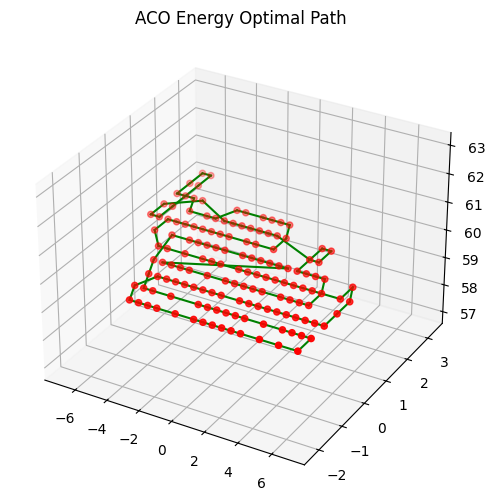

In [70]:
import numpy as np
import pandas as pd
import folium
import matplotlib.pyplot as plt
from math import cos, radians

# ==========================================================
# STEP 1 — LOAD MASTER NODES
# ==========================================================
master_df = pd.read_csv("master_slave_mapping.csv")
master_nodes = master_df["Master_Node"].values

centroid_df = pd.read_csv("grid_centroids.csv")

master_centroids = centroid_df[
    centroid_df["grid_id"].isin(master_nodes)
].reset_index(drop=True)

n_nodes = len(master_centroids)
print("Total Master Nodes:", n_nodes)

# ==========================================================
# STEP 2 — LAT/LON → PLANAR KM (VECTORISED)
# ==========================================================
lat0 = master_centroids["grid_centroid_lat"].mean()
lon0 = master_centroids["grid_centroid_lon"].mean()

lat = master_centroids["grid_centroid_lat"].values
lon = master_centroids["grid_centroid_lon"].values

x_km = (lon - lon0) * 111.32 * cos(radians(lat0))
y_km = (lat - lat0) * 110.574

master_centroids["x_km"] = x_km
master_centroids["y_km"] = y_km

# ==========================================================
# STEP 3 — CONSTANT HEIGHT
# ==========================================================
FIXED_HEIGHT = 60.0
points_3d = np.column_stack((x_km, y_km, np.full(n_nodes, FIXED_HEIGHT)))

coords = points_3d[:, :2]
n = len(coords)

# ==========================================================
# STEP 4 — DISTANCE MATRIX
# ==========================================================
dx = coords[:, 0][:, None] - coords[:, 0]
dy = coords[:, 1][:, None] - coords[:, 1]
dist_matrix = np.sqrt(dx**2 + dy**2)

# ==========================================================
# STEP 5 — ENERGY MODEL
# ==========================================================
UAV_SPEED = 2.0
CRUISE_POWER = 308.709
TURN_COEFF = 225
TURN_REF = 2.1
CORRECTION = -0.852

time_matrix = dist_matrix / UAV_SPEED
energy_dist = CRUISE_POWER * time_matrix + CORRECTION

# ==========================================================
# STEP 6 — TURN ANGLE MATRIX (STABLE)
# ==========================================================
vec = coords[:, None, :] - coords[None, :, :]
norm = np.linalg.norm(vec, axis=2, keepdims=True)
norm[norm == 0] = 1
unit_vec = vec / norm

angle_matrix = np.zeros((n, n, n), dtype=np.float32)

for j in range(n):
    v_in = unit_vec[:, j, :]
    v_out = unit_vec[j, :, :]
    dot = np.dot(v_in, v_out.T)
    dot = np.clip(dot, -1, 1)
    angle_matrix[:, j, :] = np.arccos(dot)

# Remove NaNs
angle_matrix = np.nan_to_num(angle_matrix)

turn_energy = TURN_COEFF * (angle_matrix / TURN_REF)

# ==========================================================
# STEP 7 — ACO (STABLE + FAST)
# ==========================================================
def aco_tsp_fast(alpha=1, beta=2, evap=0.5, Q=1):

    pheromone = np.ones((n, n), dtype=np.float32)
    best_path = None
    best_energy = np.inf

    n_ants = 105
    n_iter = 160
    # n_ants = n_nodes          # ✔ ants = master nodes
    # n_iter = 100
    for iteration in range(n_iter):
        print(f"Iteration {iteration+1}/{n_iter}")

        for ant in range(n_ants):

            visited = np.zeros(n, dtype=bool)
            curr = ant % n
            prev = curr
            visited[curr] = True

            path = [curr]
            energy = 0.0

            while not visited.all():

                candidates = np.where(~visited)[0]

                # Energy calculation
                e_dist = energy_dist[curr, candidates]
                e_turn = turn_energy[prev, curr, candidates]
                e_total = e_dist + e_turn

                # Remove invalid values
                e_total = np.nan_to_num(e_total, nan=1e9, posinf=1e9)

                pher = pheromone[curr, candidates] ** alpha
                heuristic = (1.0 / (e_total + 1e-6)) ** beta
                probs = pher * heuristic

                prob_sum = probs.sum()

                # Fallback if all probabilities are zero
                if prob_sum == 0 or np.isnan(prob_sum):
                    nxt = np.random.choice(candidates)
                else:
                    probs /= prob_sum
                    nxt = np.random.choice(candidates, p=probs)

                energy += energy_dist[curr, nxt]
                energy += turn_energy[prev, curr, nxt]

                visited[nxt] = True
                path.append(nxt)
                prev, curr = curr, nxt

            path.append(path[0])

            # Best solution update
            if energy < best_energy:
                best_energy = energy
                best_path = path

            # Pheromone update
            for i in range(len(path)-1):
                pheromone[path[i], path[i+1]] += Q / (energy + 1e-6)

        pheromone *= (1 - evap)

    return best_path, best_energy

# ==========================================================
# STEP 8 — RUN ACO
# ==========================================================
best_path, best_energy = aco_tsp_fast()

print("\nBest Path:", best_path)
print("Total Energy (J):", best_energy)

# ==========================================================
# STEP 9 — TOTAL DISTANCE
# ==========================================================
total_dist = sum(
    dist_matrix[best_path[i], best_path[i+1]]
    for i in range(len(best_path)-1)
)

print("Total Distance (km):", total_dist)

# ==========================================================
# STEP 10 — 3D VISUALIZATION
# ==========================================================
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(points_3d[:,0], points_3d[:,1], points_3d[:,2], c='red')

for i in range(len(best_path)-1):
    p1 = points_3d[best_path[i]]
    p2 = points_3d[best_path[i+1]]
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], 'g')

ax.set_title("ACO Energy Optimal Path")
plt.show()

# ==========================================================
# STEP 11 — FOLIUM MAP
# ==========================================================
m = folium.Map(location=[lat.mean(), lon.mean()], zoom_start=13)

for _, row in master_centroids.iterrows():
    folium.CircleMarker(
        location=[row.grid_centroid_lat, row.grid_centroid_lon],
        radius=5,
        color="red"
    ).add_to(m)

aco_coords = [
    (master_centroids.iloc[i].grid_centroid_lat,
     master_centroids.iloc[i].grid_centroid_lon)
    for i in best_path
]

folium.PolyLine(aco_coords, color="purple", weight=4).add_to(m)

m


In [73]:
import numpy as np
import pandas as pd
import folium
import matplotlib.pyplot as plt
from math import cos, radians

# ==========================================================
# STEP 1 — LOAD MASTER NODES
# ==========================================================
master_df = pd.read_csv("master_slave_mapping.csv")
master_nodes = master_df["Master_Node"].values

centroid_df = pd.read_csv("grid_centroids.csv")

master_centroids = centroid_df[
    centroid_df["grid_id"].isin(master_nodes)
].reset_index(drop=True)

n_nodes = len(master_centroids)
print("Total Master Nodes:", n_nodes)

# ==========================================================
# STEP 2 — LAT/LON → PLANAR KM
# ==========================================================
lat0 = master_centroids["grid_centroid_lat"].mean()
lon0 = master_centroids["grid_centroid_lon"].mean()

lat = master_centroids["grid_centroid_lat"].values
lon = master_centroids["grid_centroid_lon"].values

x_km = (lon - lon0) * 111.32 * cos(radians(lat0))
y_km = (lat - lat0) * 110.574

master_centroids["x_km"] = x_km
master_centroids["y_km"] = y_km

# ==========================================================
# STEP 3 — POINTS
# ==========================================================
FIXED_HEIGHT = 60.0
points_3d = np.column_stack((x_km, y_km, np.full(n_nodes, FIXED_HEIGHT)))

coords = points_3d[:, :2]
n = len(coords)

# ==========================================================
# STEP 4 — DISTANCE MATRIX (KM)
# ==========================================================
dx = coords[:, 0][:, None] - coords[:, 0]
dy = coords[:, 1][:, None] - coords[:, 1]
dist_matrix = np.sqrt(dx**2 + dy**2)   # km

# ==========================================================
# STEP 5 — ENERGY MODEL (CORRECT UNITS)
# ==========================================================
UAV_SPEED = 2.0          # m/s
CRUISE_POWER = 308.709   # Watts (J/s)
TURN_COEFF = 225
TURN_REF = 2.1
CORRECTION = -0.852

# Convert distance to meters
dist_matrix_m = dist_matrix * 1000

# Time in seconds
time_matrix = dist_matrix_m / UAV_SPEED

# Distance energy in Joules
energy_dist = CRUISE_POWER * time_matrix + CORRECTION

# ==========================================================
# STEP 6 — TURN ANGLE MATRIX
# ==========================================================
vec = coords[:, None, :] - coords[None, :, :]
norm = np.linalg.norm(vec, axis=2, keepdims=True)
norm[norm == 0] = 1
unit_vec = vec / norm

angle_matrix = np.zeros((n, n, n), dtype=np.float32)

for j in range(n):
    v_in = unit_vec[:, j, :]
    v_out = unit_vec[j, :, :]
    dot = np.dot(v_in, v_out.T)
    dot = np.clip(dot, -1, 1)
    angle_matrix[:, j, :] = np.arccos(dot)

angle_matrix = np.nan_to_num(angle_matrix)

# Turn energy (Joules)
turn_energy = TURN_COEFF * (angle_matrix / TURN_REF)

# ==========================================================
# STEP 7 — ACO (ENERGY OPTIMIZATION)
# ==========================================================
def aco_tsp_energy(alpha=1, beta=2, evap=0.5, Q=1):

    pheromone = np.ones((n, n), dtype=np.float32)
    best_path = None
    best_energy = np.inf

    n_ants = 105
    n_iter = 160

    for iteration in range(n_iter):
        print(f"Iteration {iteration+1}/{n_iter}")

        for ant in range(n_ants):

            visited = np.zeros(n, dtype=bool)
            curr = ant % n
            prev = curr
            visited[curr] = True

            path = [curr]
            energy = 0.0

            while not visited.all():

                candidates = np.where(~visited)[0]

                e_dist = energy_dist[curr, candidates]
                e_turn = turn_energy[prev, curr, candidates]
                e_total = e_dist + e_turn

                e_total = np.nan_to_num(e_total, nan=1e9, posinf=1e9)

                pher = pheromone[curr, candidates] ** alpha
                heuristic = (1.0 / (e_total + 1e-6)) ** beta
                probs = pher * heuristic

                prob_sum = probs.sum()

                if prob_sum == 0 or np.isnan(prob_sum):
                    nxt = np.random.choice(candidates)
                else:
                    probs /= prob_sum
                    nxt = np.random.choice(candidates, p=probs)

                energy += energy_dist[curr, nxt]
                energy += turn_energy[prev, curr, nxt]

                visited[nxt] = True
                path.append(nxt)
                prev, curr = curr, nxt

            path.append(path[0])

            if energy < best_energy:
                best_energy = energy
                best_path = path

            for i in range(len(path)-1):
                pheromone[path[i], path[i+1]] += Q / (energy + 1e-6)

        pheromone *= (1 - evap)

    return best_path, best_energy

# ==========================================================
# STEP 8 — RUN ACO
# ==========================================================
best_path, best_energy = aco_tsp_energy()

print("\nBest Path:", best_path)

# ==========================================================
# STEP 9 — TOTAL DISTANCE & ENERGY
# ==========================================================
total_dist_km = sum(
    dist_matrix[best_path[i], best_path[i+1]]
    for i in range(len(best_path)-1)
)

total_dist_m = total_dist_km * 1000
energy_wh = best_energy / 3600

print("\n====================================")
print("ACO TSP PERFORMANCE (Distance + Energy)")
print("====================================")
print("Nodes Visited        :", len(best_path)-1)
print("Total Distance (km)  :", round(total_dist_km, 3))
print("Total Distance (m)   :", round(total_dist_m, 2))
print("Total Energy (J)     :", round(best_energy, 2))
print("Energy (Wh)          :", round(energy_wh, 2))
print("====================================\n")

# ==========================================================
# STEP 10 — MAP
# ==========================================================
m = folium.Map(location=[lat.mean(), lon.mean()], zoom_start=13)

for _, row in master_centroids.iterrows():
    folium.CircleMarker(
        location=[row.grid_centroid_lat, row.grid_centroid_lon],
        radius=5,
        color="red"
    ).add_to(m)

aco_coords = [
    (master_centroids.iloc[i].grid_centroid_lat,
     master_centroids.iloc[i].grid_centroid_lon)
    for i in best_path
]

folium.PolyLine(aco_coords, color="purple", weight=4).add_to(m)

m


Total Master Nodes: 144
Iteration 1/160
Iteration 2/160
Iteration 3/160
Iteration 4/160
Iteration 5/160
Iteration 6/160
Iteration 7/160
Iteration 8/160
Iteration 9/160
Iteration 10/160
Iteration 11/160
Iteration 12/160
Iteration 13/160
Iteration 14/160
Iteration 15/160
Iteration 16/160
Iteration 17/160
Iteration 18/160
Iteration 19/160
Iteration 20/160
Iteration 21/160
Iteration 22/160
Iteration 23/160
Iteration 24/160
Iteration 25/160
Iteration 26/160
Iteration 27/160
Iteration 28/160
Iteration 29/160
Iteration 30/160
Iteration 31/160
Iteration 32/160
Iteration 33/160
Iteration 34/160
Iteration 35/160
Iteration 36/160
Iteration 37/160
Iteration 38/160
Iteration 39/160
Iteration 40/160
Iteration 41/160
Iteration 42/160
Iteration 43/160
Iteration 44/160
Iteration 45/160
Iteration 46/160
Iteration 47/160
Iteration 48/160
Iteration 49/160
Iteration 50/160
Iteration 51/160
Iteration 52/160
Iteration 53/160
Iteration 54/160
Iteration 55/160
Iteration 56/160
Iteration 57/160
Iteration 58/160

In [74]:
# ==========================================================
# STEP 8 — CONSISTENT DISTANCE + ENERGY (MATCHES STEP-9)
# ==========================================================

# ---------- UAV PARAMETERS ----------
UAV_SPEED = 2.0        # m/s
CRUISE_POWER = 308.709 # Watts (J/s)
TURN_COEFF = 225
TURN_REF = 2.1
CORRECTION = -0.852


# ==========================================================
# STEP 8A — PRECOMPUTE ENERGY MATRICES (METERS)
# ==========================================================

# dist_matrix is in km → convert to meters
dist_matrix_m = dist_matrix * 1000

# Distance energy (Joules)
time_matrix = dist_matrix_m / UAV_SPEED
energy_dist = CRUISE_POWER * time_matrix + CORRECTION

# Turn energy (angle_matrix already in radians)
turn_energy = TURN_COEFF * (angle_matrix / TURN_REF)


# ==========================================================
# STEP 8B — TOTAL DISTANCE
# ==========================================================
def compute_total_distance_km(dist_matrix, path):
    total = 0.0
    for i in range(len(path)-1):
        total += dist_matrix[path[i], path[i+1]]
    return total


# ==========================================================
# STEP 8C — TOTAL ENERGY (REAL JOULES)
# ==========================================================
def compute_total_energy(path):
    total_E = 0.0

    # First segment (distance only)
    curr = path[0]
    nxt = path[1]
    total_E += energy_dist[curr, nxt]

    # Remaining segments (distance + turn)
    for i in range(1, len(path)-1):
        prev = path[i-1]
        curr = path[i]
        nxt = path[i+1]

        total_E += energy_dist[curr, nxt]
        total_E += turn_energy[prev, curr, nxt]

    return total_E


# ==========================================================
# STEP 8D — METRICS WINDOW
# ==========================================================
total_dist_km = compute_total_distance_km(dist_matrix, best_path)
total_dist_m = total_dist_km * 1000

total_energy_j = compute_total_energy(best_path)
energy_wh = total_energy_j / 3600

print("\n====================================")
print("ACO TSP PERFORMANCE (Distance + Energy)")
print("====================================")
print("Nodes Visited        :", len(best_path)-1)
print("Total Distance (km)  :", round(total_dist_km, 3))
print("Total Distance (m)   :", round(total_dist_m, 2))
print("Total Energy (J)     :", round(total_energy_j, 2))
print("Energy (Wh)          :", round(energy_wh, 2))
print("====================================\n")



ACO TSP PERFORMANCE (Distance + Energy)
Nodes Visited        : 144
Total Distance (km)  : 89.946
Total Distance (m)   : 89946.35
Total Energy (J)     : 13897975.24
Energy (Wh)          : 3860.55



In [75]:
import numpy as np
import pandas as pd
import folium
import matplotlib.pyplot as plt
from math import cos, radians

# ==========================================================
# STEP 1 — LOAD MASTER NODES
# ==========================================================
master_df = pd.read_csv("master_slave_mapping.csv")
master_nodes = master_df["Master_Node"].values

centroid_df = pd.read_csv("grid_centroids.csv")

master_centroids = centroid_df[
    centroid_df["grid_id"].isin(master_nodes)
].reset_index(drop=True)

n_nodes = len(master_centroids)
print("Total Master Nodes:", n_nodes)

# ==========================================================
# STEP 2 — LAT/LON → PLANAR KM
# ==========================================================
lat0 = master_centroids["grid_centroid_lat"].mean()
lon0 = master_centroids["grid_centroid_lon"].mean()

lat = master_centroids["grid_centroid_lat"].values
lon = master_centroids["grid_centroid_lon"].values

x_km = (lon - lon0) * 111.32 * cos(radians(lat0))
y_km = (lat - lat0) * 110.574

master_centroids["x_km"] = x_km
master_centroids["y_km"] = y_km

# ==========================================================
# STEP 3 — POINTS
# ==========================================================
FIXED_HEIGHT = 60.0
points_3d = np.column_stack((x_km, y_km, np.full(n_nodes, FIXED_HEIGHT)))

coords = points_3d[:, :2]
n = len(coords)

# ==========================================================
# STEP 4 — DISTANCE MATRIX (KM)
# ==========================================================
dx = coords[:, 0][:, None] - coords[:, 0]
dy = coords[:, 1][:, None] - coords[:, 1]
dist_matrix = np.sqrt(dx**2 + dy**2)   # km

# ==========================================================
# STEP 5 — ENERGY MODEL (CORRECT UNITS)
# ==========================================================
UAV_SPEED = 2.0          # m/s
CRUISE_POWER = 308.709   # Watts (J/s)
TURN_COEFF = 225
TURN_REF = 2.1
CORRECTION = -0.852

# Convert distance to meters
dist_matrix_m = dist_matrix * 1000

# Time in seconds
time_matrix = dist_matrix_m / UAV_SPEED

# Distance energy in Joules
energy_dist = CRUISE_POWER * time_matrix + CORRECTION

# ==========================================================
# STEP 6 — TURN ANGLE MATRIX
# ==========================================================
vec = coords[:, None, :] - coords[None, :, :]
norm = np.linalg.norm(vec, axis=2, keepdims=True)
norm[norm == 0] = 1
unit_vec = vec / norm

angle_matrix = np.zeros((n, n, n), dtype=np.float32)

for j in range(n):
    v_in = unit_vec[:, j, :]
    v_out = unit_vec[j, :, :]
    dot = np.dot(v_in, v_out.T)
    dot = np.clip(dot, -1, 1)
    angle_matrix[:, j, :] = np.arccos(dot)

angle_matrix = np.nan_to_num(angle_matrix)

# Turn energy (Joules)
turn_energy = TURN_COEFF * (angle_matrix / TURN_REF)

# ==========================================================
# STEP 7 — ACO (ENERGY OPTIMIZATION)
# ==========================================================
def aco_tsp_energy(alpha=1, beta=2, evap=0.5, Q=1):

    pheromone = np.ones((n, n), dtype=np.float32)
    best_path = None
    best_energy = np.inf

    n_ants = n
    n_iter = 100

    for iteration in range(n_iter):
        print(f"Iteration {iteration+1}/{n_iter}")

        for ant in range(n_ants):

            visited = np.zeros(n, dtype=bool)
            curr = ant % n
            prev = curr
            visited[curr] = True

            path = [curr]
            energy = 0.0

            while not visited.all():

                candidates = np.where(~visited)[0]

                e_dist = energy_dist[curr, candidates]
                e_turn = turn_energy[prev, curr, candidates]
                e_total = e_dist + e_turn

                e_total = np.nan_to_num(e_total, nan=1e9, posinf=1e9)

                pher = pheromone[curr, candidates] ** alpha
                heuristic = (1.0 / (e_total + 1e-6)) ** beta
                probs = pher * heuristic

                prob_sum = probs.sum()

                if prob_sum == 0 or np.isnan(prob_sum):
                    nxt = np.random.choice(candidates)
                else:
                    probs /= prob_sum
                    nxt = np.random.choice(candidates, p=probs)

                energy += energy_dist[curr, nxt]
                energy += turn_energy[prev, curr, nxt]

                visited[nxt] = True
                path.append(nxt)
                prev, curr = curr, nxt

            path.append(path[0])

            if energy < best_energy:
                best_energy = energy
                best_path = path

            for i in range(len(path)-1):
                pheromone[path[i], path[i+1]] += Q / (energy + 1e-6)

        pheromone *= (1 - evap)

    return best_path, best_energy

# ==========================================================
# STEP 8 — RUN ACO
# ==========================================================
best_path, best_energy = aco_tsp_energy()

print("\nBest Path:", best_path)

# ==========================================================
# STEP 9 — TOTAL DISTANCE & ENERGY
# ==========================================================
total_dist_km = sum(
    dist_matrix[best_path[i], best_path[i+1]]
    for i in range(len(best_path)-1)
)

total_dist_m = total_dist_km * 1000
energy_wh = best_energy / 3600

print("\n====================================")
print("ACO TSP PERFORMANCE (Distance + Energy)")
print("====================================")
print("Nodes Visited        :", len(best_path)-1)
print("Total Distance (km)  :", round(total_dist_km, 3))
print("Total Distance (m)   :", round(total_dist_m, 2))
print("Total Energy (J)     :", round(best_energy, 2))
print("Energy (Wh)          :", round(energy_wh, 2))
print("====================================\n")

# ==========================================================
# STEP 10 — MAP
# ==========================================================
m = folium.Map(location=[lat.mean(), lon.mean()], zoom_start=13)

for _, row in master_centroids.iterrows():
    folium.CircleMarker(
        location=[row.grid_centroid_lat, row.grid_centroid_lon],
        radius=5,
        color="red"
    ).add_to(m)

aco_coords = [
    (master_centroids.iloc[i].grid_centroid_lat,
     master_centroids.iloc[i].grid_centroid_lon)
    for i in best_path
]

folium.PolyLine(aco_coords, color="purple", weight=4).add_to(m)

m


Total Master Nodes: 144
Iteration 1/100
Iteration 2/100
Iteration 3/100
Iteration 4/100
Iteration 5/100
Iteration 6/100
Iteration 7/100
Iteration 8/100
Iteration 9/100
Iteration 10/100
Iteration 11/100
Iteration 12/100
Iteration 13/100
Iteration 14/100
Iteration 15/100
Iteration 16/100
Iteration 17/100
Iteration 18/100
Iteration 19/100
Iteration 20/100
Iteration 21/100
Iteration 22/100
Iteration 23/100
Iteration 24/100
Iteration 25/100
Iteration 26/100
Iteration 27/100
Iteration 28/100
Iteration 29/100
Iteration 30/100
Iteration 31/100
Iteration 32/100
Iteration 33/100
Iteration 34/100
Iteration 35/100
Iteration 36/100
Iteration 37/100
Iteration 38/100
Iteration 39/100
Iteration 40/100
Iteration 41/100
Iteration 42/100
Iteration 43/100
Iteration 44/100
Iteration 45/100
Iteration 46/100
Iteration 47/100
Iteration 48/100
Iteration 49/100
Iteration 50/100
Iteration 51/100
Iteration 52/100
Iteration 53/100
Iteration 54/100
Iteration 55/100
Iteration 56/100
Iteration 57/100
Iteration 58/100

In [79]:
# ==========================================================
# TOTAL UAV ENERGY IN JOULES (SAFE, DISTANCE IN KM)
# ==========================================================

import numpy as np
import math

# ----------------------------------------------------------
# PHYSICAL CONSTANTS (SI UNITS)
# ----------------------------------------------------------
UAV_SPEED = 2.0          # m/s
CRUISE_POWER = 308.709   # Watts (J/s)
TURN_COEFF = 225.0       # Joules per radian (turning effort)
FIXED_HEIGHT = 60.0      # meters
KM_TO_M = 1000.0

# ----------------------------------------------------------
# BUILD 3D POINTS (x_km, y_km, z_m)
# ----------------------------------------------------------
points_3d = np.array([
    (row.x_km, row.y_km, FIXED_HEIGHT)
    for _, row in master_centroids.iterrows()
])

n_points = len(points_3d)

# ----------------------------------------------------------
# ANGLE CALCULATION (ROBUST)
# ----------------------------------------------------------
def deviation_angle(p_prev, p_curr, p_next):
    vA = np.array(p_prev[:2]) - np.array(p_curr[:2])
    vB = np.array(p_next[:2]) - np.array(p_curr[:2])

    magA = np.linalg.norm(vA)
    magB = np.linalg.norm(vB)

    if magA == 0 or magB == 0:
        return 0.0

    cos_theta = np.clip(
        np.dot(vA, vB) / (magA * magB),
        -1.0,
        1.0
    )

    return math.acos(cos_theta)  # radians

# ----------------------------------------------------------
# ENERGY COST FOR ONE MOVE (JOULES)
# ----------------------------------------------------------
def energy_cost_joules(p_prev, p_curr, p_next):
    # distance in km (from coordinates)
    dist_km = np.linalg.norm(p_next[:2] - p_curr[:2])

    # convert km → meters
    dist_m = dist_km * KM_TO_M

    # flight time (seconds)
    time_s = dist_m / UAV_SPEED

    # cruise energy (J)
    E_cruise = CRUISE_POWER * time_s

    # turning energy (J)
    angle_rad = deviation_angle(p_prev, p_curr, p_next)
    E_turn = TURN_COEFF * angle_rad

    return E_cruise + E_turn

# ----------------------------------------------------------
# TOTAL ENERGY OF A GIVEN PATH (SAFE)
# ----------------------------------------------------------
def total_energy_joules(points, path):
    total_energy = 0.0
    n_pts = len(points)

    for i in range(len(path) - 2):
        idx_prev = path[i]
        idx_curr = path[i + 1]
        idx_next = path[i + 2]

        # ---- SAFETY CHECK ----
        if (
            idx_prev >= n_pts or
            idx_curr >= n_pts or
            idx_next >= n_pts
        ):
            continue

        p_prev = points[idx_prev]
        p_curr = points[idx_curr]
        p_next = points[idx_next]

        total_energy += energy_cost_joules(
            p_prev, p_curr, p_next
        )

    return total_energy

# ----------------------------------------------------------
# CALCULATE ENERGY OF BEST PATH
# ----------------------------------------------------------
print("Max index in best_path:", max(best_path))
print("Total available points:", n_points)

total_energy_J = total_energy_joules(points_3d, best_path)

print("\n⚡ Total UAV Energy (Joules):")
print(f"   {total_energy_J:,.2f} J")


Max index in best_path: 143
Total available points: 144

⚡ Total UAV Energy (Joules):
   15,055,237.05 J


In [63]:
# ==========================================================
# STEP 9 — ENERGY CALCULATION (ACO-COMPATIBLE UNITS)
# ==========================================================

import math
import numpy as np

# -----------------------------
# ENERGY MODEL CONSTANTS
# -----------------------------
UAV_SPEED = 2.0          # m/s
CRUISE_POWER = 308.709   # W
TURN_COEFF = 225
TURN_REF = 2.1
CORRECTION = -0.852
FIXED_HEIGHT = 60.0      # meters

# -----------------------------
# BUILD 3D POINTS (KM, KM, M)
# -----------------------------
points_3d = np.array([
    (row.x_km, row.y_km, FIXED_HEIGHT)
    for _, row in master_centroids.iterrows()
])

# -----------------------------
# HELPER FUNCTIONS
# -----------------------------
def dot(vA, vB):
    return vA[0]*vB[0] + vA[1]*vB[1]

def deviation_angle(p_prev, p_curr, p_next):
    if np.allclose(p_prev[:2], p_curr[:2]):
        return 0.0

    vA = [p_prev[0] - p_curr[0], p_prev[1] - p_curr[1]]
    vB = [p_next[0] - p_curr[0], p_next[1] - p_curr[1]]

    dot_prod = dot(vA, vB)
    magA = math.sqrt(dot(vA, vA))
    magB = math.sqrt(dot(vB, vB))

    cos_theta = np.clip(dot_prod / (magA * magB), -1, 1)
    angle = math.degrees(math.acos(cos_theta))

    return min(angle, 360 - angle)

# -----------------------------
# ENERGY COST (MATCHES ACO UNITS)
# -----------------------------
def energy_cost_aco_units(p_prev, p_curr, p_next):
    # distance in kilometers (same as ACO)
    dist_km = np.linalg.norm(p_next - p_curr)

    # same scaled time as ACO
    time = dist_km / UAV_SPEED          # km / (m/s)

    E_dist = CRUISE_POWER * time + CORRECTION

    angle = deviation_angle(p_prev, p_curr, p_next)
    E_turn = TURN_COEFF * (math.radians(angle) / TURN_REF) if angle > 0 else 0

    return E_dist + E_turn

# -----------------------------
# TOTAL ENERGY FOR ACO PATH
# -----------------------------
total_energy_aco_units = 0.0

for i in range(1, len(best_path) - 1):
    p_prev = points_3d[best_path[i - 1]]
    p_curr = points_3d[best_path[i]]
    p_next = points_3d[best_path[i + 1]]

    total_energy_aco_units += energy_cost_aco_units(
        p_prev, p_curr, p_next
    )

print(f"\n⚡ Total UAV Energy (ACO-Compatible Units): {total_energy_aco_units:.2f}")



⚡ Total UAV Energy (ACO-Compatible Units): 58148.30


In [ ]:
# # ==========================================================
# # ENERGY CALCULATION FOR EXISTING ACO-TSP PATH
# # (USING SAME MODEL AS YOUR PREVIOUS ENERGY CODE)
# # ==========================================================

# import math
# import numpy as np

# # -----------------------------
# # CONSTANTS (SAME AS BEFORE)
# # -----------------------------
# UAV_SPEED = 2.0          # m/s
# CRUISE_POWER = 308.709   # W
# TURN_COEFF = 225
# TURN_REF = 2.1
# CORRECTION = -0.852
# FIXED_HEIGHT = 60.0      # meters

# # -----------------------------
# # BUILD 3D POINTS FROM TSP ORDER
# # -----------------------------
# points_3d = np.array([
#     (row.x_km, row.y_km, FIXED_HEIGHT)
#     for _, row in master_centroids.iterrows()
# ])

# # -----------------------------
# # ANGLE + ENERGY FUNCTIONS
# # -----------------------------
# def dot(vA, vB):
#     return vA[0]*vB[0] + vA[1]*vB[1]

# def deviation_angle(p_prev, p_curr, p_next):
#     if np.allclose(p_prev[:2], p_curr[:2]):
#         return 0.0

#     vA = [p_prev[0] - p_curr[0], p_prev[1] - p_curr[1]]
#     vB = [p_next[0] - p_curr[0], p_next[1] - p_curr[1]]

#     dot_prod = dot(vA, vB)
#     magA = math.sqrt(dot(vA, vA))
#     magB = math.sqrt(dot(vB, vB))

#     cos_theta = np.clip(dot_prod / (magA * magB), -1, 1)
#     angle = math.degrees(math.acos(cos_theta))

#     return min(angle, 360 - angle)

# def energy_cost(p_prev, p_curr, p_next):
#     dist = np.linalg.norm(p_next - p_curr)     # km
#     time = (dist * 1000) / UAV_SPEED           # seconds

#     E_dist = CRUISE_POWER * time + CORRECTION

#     angle = deviation_angle(p_prev, p_curr, p_next)
#     E_turn = TURN_COEFF * (math.radians(angle) / TURN_REF) if angle > 0 else 0

#     return E_dist + E_turn

# # -----------------------------
# # TOTAL ENERGY OF ACO-TSP PATH
# # -----------------------------
# total_energy = 0.0

# for i in range(1, len(best_path) - 1):
#     p_prev = points_3d[best_path[i - 1]]
#     p_curr = points_3d[best_path[i]]
#     p_next = points_3d[best_path[i + 1]]

#     total_energy += energy_cost(p_prev, p_curr, p_next)

# print(f"🔋 Total UAV Energy for ACO-TSP Path: {total_energy:.2f} Joules")
